# Trading Strategy: BUY at Market Open

## Key Scenario
- **Decision Point**: Market open (start of day)
- **Information Available**: 
  - ✅ Previous day's complete OHLCV data
  - ✅ Today's OPEN price only
  - ❌ Today's High, Low, Close, Volume (unknown at decision time)

## Feature Engineering Strategy
All features are constructed using:
1. **Historical data** (t-1, t-2, ...): Complete OHLCV bars
2. **Current day** (t): Only the OPEN price
3. **Gap feature**: `gap_prevclose_to_open` = (today_Open / prev_Close) - 1.0

This ensures **zero lookahead bias** - we only use information available at market open.

## Label Strategy
- **Target**: Predict if stock will rise by `PROFIT_THRESHOLD` (e.g., 1.5%) from **today's OPEN**
- **Horizon**: Look ahead `HORIZON_BARS` (e.g., 2 days)
- **Label = 1**: If max(OHLC) over next HORIZON_BARS ≥ Open * (1 + PROFIT_THRESHOLD)
- **Label = 0**: Otherwise

## Production Usage
When scanning stocks in real-time:
1. Download historical data + today's open
2. Features automatically use only previous complete bars + today's open
3. Model predicts probability of hitting profit target
4. Buy if probability > BUY_THRESHOLD

In [ ]:
# Tickers

TICKERS = [
    # Nasdaq 100 / major large caps (~100)
    "AAPL","MSFT","NVDA","GOOGL","AMZN","META","TSLA","AVGO","PEP","COST",
    "CMCSA","ADBE","INTC","QCOM","TXN","AMD","PDD","AMAT","CSCO","INTU",
    "ISRG","MDLZ","CHTR","SBUX","GILD","TMUS","VRTX","BIIB","MAR","HON",
    "MU","BKNG","ILMN","ADI","ZM","REGN","LRCX","ADSK","KLAC","SNPS",
    "NXPI","MRVL","CTAS","MELI","TEAM","EA","KLAC","WDAY","EXC","SBAC",
    "EBAY","ROST","CTSH","OKTA","CDNS","LULU","ALGN","KHC","XEL","ASML",
    "DXCM","PCAR","ORLY","ILMN","ADP","VRSK","SIRI","WDC","TTWO","BSX",
    "VRSN","BIDU","CPRT","TYL","BR","DLTR","FAST","NNVC","UAL","RBLX",
    "OKTA","DOCU","ZS","SWKS","ULTA",

    # Growth + mid/small caps (~200 more)
    "ABNB","CRWD","SNOW","COIN","UPST","RIVN","PLTR","BNGO","SOFI","RKT",
    "SPOT","ZM","PTON","FSLY","ETSY","PINS","ROKU","TWLO","OKTA","DOCU",
    "GDRX","DKNG","GLBE","LCID","NIO","LI","WKHS","BLDP","FUBO","BILI",
    "BEAM","IONS","ADIL","BMBL","APP","HPQ","SYNA","ASTE","APPS","ASAN",
    "CHWY","CLOV","CMG","CRSP","DNUT","DKS","FROG","FVRR","GH","HIMS",
    "JBLU","KPTI","LOGI","MSTR","NEOG","NTRA","OPEN","ORGN","PACB","PEGA",
    "PSTG","QBTS","RAMP","SABR","SHOP","SIGA","SMCI","SPCB","SSNC","TER",
    "TRUP","TSCO","TTD","UPWK","VAXX","VICI","VIR","VNET","XPEL","YETI",
    "Z","ZTO","ZYXI",

    # Additional Nasdaq names (~50–100 fill to ~300)
    "ACAD","ACGL","ACHC","ACIW","ALNY","AMKR","AMN","ASML","BCRX","BFS",
    "BOH","BOOT","BPTH","BSY","CGEN","CODA","COHU","CRLBF","CYBR","CYTK",
    "DLB","DNLI","EIX","ENTA","ENVX","ESTC","EVGO","EXAS","FTCI","GPT",
    "HUBS","INO","IPI","IRMD","JAKK","KURA","LAZR","LCTX","MARA","MMSI",
    "MNKD","NERV","NXST","OBIO","OCGN","ONON","OSPN","QDEL","RERE","RLAY",
    "SHOT","SMTC","STNE","SUPN","SWBI","TDC","TNL","TRIN","VRA","XRAY",

    "BAC", "NFLX", "KO", "CSCO", "WFC", "INTC", "NEE", "UBER", "T", "VZ",
    "PFE", "BSX", "IBKR", "COP", "BN", "BMY",

    "CVS", "CCZ", "MO", "SO", "NKE", "USB", "NU", "BAM", "FCX", "ORLY",
    "GLW", "MNST", "WMB", "GM", "MDLZ", "SLB", "EPD",

    "CSX", "KMI", "TFC", "ET", "RKT", "FTNT", "O", "MPLX", "NDAQ", "SRE",
    "F", "CMG", "BKR", "PYPL", "RBLX", "FAST",

    "LVS", "CCEP", "CPRT", "PEG", "KR", "XYZ", "AIG", "SYM", "CCI", "VTR",
    "CCL", "KDP", "JD", "GEHC", "SYY", "CPNG",

    "FIS", "VIK", "VICI", "ROL", "FOX", "AMRZ", "FWONA", "HPE", "DXCM",
    "HAL", "CSGP", "TSCO", "SYF", "HBAN", "CFG", "IRM",

    # Crypto / miners / energy-adjacent
    "CIFR","WULF","HUT","CORZ","BITF","CLSK","IREN","RIOT","MARA","RKLB",
    "UUUU","UEC","HYMC","SSRM","PHYS","EQX",

    # AI / semis / tech
    "AAOI","AMPX","SERV","AEVA","APLD","NVTS","ONDS","CRWV","FIG",
    "SOUL","IMSR","FIGR","GLXY",

    # Growth / speculative
    "SOUN","RGTI","JOBY","LUNR","OKLO","NBIS","EOSE","CRCL","UMAC",
    "ATXS","VTYX","AEVA","BMNR","MCDIF",

    # Industrials / transports / materials
    "AAL","ALK","DAL","CLF","AA","MP","DVN","SGML","EQT","PAA","OSS",

    # Financials / REITs / income
    "AGNC","FITB","COLB","RF","SLM","PSLV",

    # Healthcare / biotech
    "MRNA","QURE","FOLD","MKC",

    # Misc / other
    "RUN","PL","CDE","SOUL","SOC","SKYT","LIF","ROIV",

    "CLPT","SO","KDP","DOW","GM","FISV","KR","QXO","WMB","IRDM",
    "ORLY","BTDR","LMND","CPB","DAY","FHN","COMP",

    "LKSP","VSNT","DRDB","ACI","GFS","S","IBKR","AVTR","BKH",
    "NWE","AR","RAPT","APGE","GIS","GAP","MCHP","RITM",

    "AES","CRK","CPRT","SYF","OWL","XEL","XP","O","AMBQ",
    "DOC","FLY","DOGZ","MO","IP","AMCR","AEO","JHX",

    "OCUL","LUV","GPK","FE","CL","AMKR","OKE","DBRG",
    "HCMA","GEHC","CART","DOCU","SEDG","AFRM","VTRS",
    "MMYT","FACT","ORI",

    "BAX","BZ","PDI","KSS","MGY","ASAN","HST","RRC",
    "SRPT","DXYZ","TTMI","SRAD","DHT","NOV","STWD",
    "DX","MIR"
]

MORE_TICKERS = [
    # Industrials / Manufacturing
    "EMR","ETN","PH","ROK","DOV","ITW","PCAR","IR","CMI","XYL",
    "WAB","NDSN","ALLE","AOS","MAS","RPM","GGG","GWW","FAST",
    "URI","HWM","CR","MLI","KMT","FLOW","SPXC","IEX","CW",

    # Energy (E&P, services, midstream)
    "XOM","CVX","OXY","EOG","PXD","APA","HES","MRO","CDEV",
    "OVV","MTDR","SM","SWN","CHK","CNX","HP","LBRT","PTEN",
    "NBR","HALO","TDW","RIG","BORR","DO","VAL",

    # Utilities
    "AEP","ED","DUK","EIX","DTE","PPL","PNW","OGE","IDA",
    "AVA","CNP","CMS","ALE","OTTR","NI","LNT","NRG","UGI",

    # Materials / Chemicals
    "LIN","APD","ECL","SHW","PPG","AXTA","CE","ALB","SQM",
    "LTHM","CF","MOS","NTR","FMC","IFF","OLN","KRO","TROX",
    "HWKN","SXT","ASH",

    # Financials (banks, insurance, alt)
    "JPM","GS","MS","C","PNC","MTB","KEY","ZION","CMA",
    "PBCT","WAL","PACW","FRC","EWBC","HOPE","BPOP","CADE",
    "AJG","AON","BRO","MKL","RNR","WRB","HIG","ALL","TRV",
    "MET","PRU","LNC","AFL","UNM","CINF","PFG","FNF","FAF",

    # Asset managers / exchanges
    "BLK","TROW","BEN","IVZ","AMG","AB","SEIC","LAZ","CG",
    "NTRS","STT","ICE","CBOE","MKTX","LPLA","SF","OPY",

    # REITs (diversified)
    "PLD","EQIX","DLR","AVB","EQR","ESS","MAA","UDR",
    "SPG","MAC","KIM","REG","FRT","BXP","HIW","SLG",
    "ARE","VNO","PEAK","WELL","HR","DOCN","NSA",

    # Consumer discretionary
    "HD","LOW","BBY","TGT","DG","FIVE","TJX","BURL",
    "RL","PVH","UAA","UA","COLM","DECK","SKX","CROX",
    "HAS","MAT","LEVI","VSCO","ANF","URBN","HIBB",
    "WING","SHAK","JACK","TXRH","YUM","QSR","DRI",

    # Consumer staples
    "PG","CLX","KMB","CHD","EL","CL","HRL","SJM",
    "CAG","TSN","BG","FLO","LW","TAP","SAM","STZ",
    "PPC","USFD","CHEF","VITL","CALM",

    # Healthcare (devices, services, pharma)
    "UNH","CI","HUM","CNC","ELV","MOH","OSCR","HCA",
    "UHS","THC","ACHC","SEM","DOCS","OMCL","MMSI",
    "HOLX","TFX","STE","PODD","EW","ZBH","MDT",
    "BHC","PRGO","RDY","TEVA","SNY","AZN","GSK",
    "NVS","TAK","BAYRY","BIIB","INCY","EXEL",

    # Biotech / life sciences (small & mid)
    "ARWR","SGEN","ALKS","IONS","BLUE","EDIT","NTLA",
    "BEAM","CRBU","VKTX","KRTX","RXRX","DNA","ABCL",
    "IMVT","CYTK","MOR","ADMA","FATE","IOVA",

    # Tech (software / infra / hardware)
    "ORCL","IBM","DELL","HPE","NTAP","PSTG","WDC","STX",
    "ANET","FIVN","NET","DDOG","MDB","ESTC","SPLK",
    "PANW","CRWD","S","TENB","RPD","GEN","AVGO",
    "LSCC","OLED","COHR","ONTO","FORM","ACLS",
    "INTA","PAYC","PAY","BILL","SMAR","CFLT",

    # Media / internet / gaming
    "DIS","WBD","PARA","SONY","NTDOY","EA","ATVI",
    "TTWO","ZNGA","MTCH","IAC","ANGI","ZG","YELP",
    "DUOL","COUR","UDMY","SPOT","WMG","LYV",

    # Industrials – transport & logistics
    "UPS","FDX","ODFL","SAIA","XPO","RXO","JBHT",
    "KNX","WERN","LSTR","CSX","NSC","UNP","CP",
    "CNI","GATX","TRN","GBX","ARCB",

    # Aerospace / defense
    "LMT","NOC","GD","RTX","BA","LHX","TXT",
    "BWXT","AVAV","KTOS","SPR","HXL","CWST",

    # Agriculture / food production
    "DE","AGCO","CNHI","DAR","SMG","FMC","MOS",
    "TSN","BG","NOMD","DOLE","VITL",

    # International ADRs (non-US exposure)
    "BABA","JD","NTES","PDD","TCOM","YUMC","BIDU",
    "TCEHY","SE","GRAB","MELI","STNE","NU",
    "VALE","PBR","ITUB","BBD","BSBR","GGB",
    "RIO","BHP","SCCO","FCX","TECK",
    "UL","RBGLY","NSRGY","HEINY","ABEV",

    # Random but legit depth names
    "RHI","MAN","KFY","CBRE","JLL","CWK","FRPT",
    "WOOF","PETQ","TRUP","IDXX","CHE","LFUS",
    "AZPN","MANH","PSN","SSB","BANF","WSBC",
    "TCBI","UCBI","IBTX","COLB","FFIN","UBSI"
]


TICKERS += MORE_TICKERS
PROBLEM_TICKERS = {
    "ATVI","AZPN","BLUE","CDEV","CHK","CNHI","DO","FRC","HES","HIBB",
    "IBTX","KRTX","LTHM","MOR","MRO","PACW","PARA","PBCT","PEAK","PETQ",
    "PXD","SGEN","SHOT","SKX","SMAR","SPLK","SWN","UCBI","ZNGA"
}
TICKERS = sorted(set(TICKERS) - PROBLEM_TICKERS)

#TICKERS = TICKERS[:100]

In [ ]:
# Example NASDAQ tickers

SEED = 42



# ====== HYPERPARAMETERS ======
# Date range for downloading & filtering price data
import pandas as pd
import datetime

INTERVAL = "1d"
START_DATE = pd.Timestamp("2024-01-01")            # inclusive
END_DATE = pd.Timestamp(datetime.date.today())        # inclusive # TODO :: ENABLE THIS AND COMMENT THE NEXT LINE IF YOU WANT TO USE IN PRODUCTION
# WARNING :: DON'T FORGET TO DELETE THE OLD CSVS WHEN YOU CHANGE DATES

# =========================
# GLOBAL DATE SPLIT CONFIG  ✅ EDIT THESE
# =========================
# Train: samples with Date <= TRAIN_END_DATE (minus embargo at boundary)
# Val:   (TRAIN_END_DATE, VAL_END_DATE] (minus embargo at boundary)
# Test:  Date > VAL_END_DATE
TRAIN_END_DATE = pd.Timestamp("2025-11-30")
VAL_END_DATE   = pd.Timestamp("2026-01-20")

REBUILD_FEATURE_CACHE = True  # set True if you change features/WINDOW and want to recompute

# Exclusion window: any bars with Date in [EXCLUDE_START_DATE, EXCLUDE_END_DATE] will be removed
# Format: any pandas-parsable string (YYYY-MM-DD recommended). These are applied during CSV featurize.
EXCLUDE_START_DATE = "2019-09-01"  # inclusive
EXCLUDE_END_DATE   = "2023-06-30"  # inclusive

# ===== TRADING SCENARIO =====
# We BUY at market OPEN using only information available at market open:
# - Previous day's complete OHLCV data
# - Current day's OPEN price only (no High, Low, Close, Volume known yet)
# 
# Labeling config:
# HORIZON_BARS: how many future bars to look ahead for a profit hit
# PROFIT_THRESHOLD: required gain relative to CURRENT DAY'S OPEN to call it a BUY (label = 1)
# STOP_LOSS: maximum loss allowed (as a negative percentage) before trade is invalidated
HORIZON_BARS = 0            # look-ahead window length (e.g. 2 daily bars)
PROFIT_THRESHOLD = 1/100    # 0.790%% profit target vs current day's OPEN price
STOP_LOSS = -2/100         # -2%% stop loss vs current day's OPEN price (negative value)
WINDOW = 30                 # look back window for features

# Training config
MAX_EPOCHS = 50
PATIENCE = 10                    # early stopping patience (not yet wired)
MIN_DELTA_MSE = 0.0             # kept for backward compatibility

# Weighted BCE threshold for buy decision
BUY_THRESHOLD = 0.5  # probability must be greater than this to be considered a BUY

# Graphs
UPDATE_EVERY = 5                # update the live-plot after how many mini-batches (legacy, not used)
PLOT_GRAPH1_EPOCH_INTERVAL = 1  # update train/test metrics (graph 1) every N epochs
PLOT_GRAPH2_BATCH_INTERVAL = 5  # update Pred vs Actual (graph 2) every N epochs
PLOT_GRAPH3_EPOCH_INTERVAL = 1  # update train vs test accuracy (graph 3) every N epochs

# Optimizer config
BATCH_SIZE = 64
WEIGHT_DECAY = 1e-4

# Model architecture config
HIDDEN_SIZES =  [64] #[1024, 512] #[256, 128] # [512, 256, 128]

# Data split config (time-based)
SPLIT_FRAC = 0.85  # train/test split fraction by time

# DataLoader config

NUM_WORKERS = 16  # Adjust based on your system (e.g., 0 for debugging, 4+ for speed)


In [194]:
# Step 1: download NASDAQ data into the *dataset* directory using yfinance (DAILY)
from pathlib import Path
import pandas as pd
import yfinance as yf

# Root directory where yfinance CSVs will be stored
data_root = Path.cwd() / "dataset"
stocks_dir = data_root / "stocks"
stocks_dir.mkdir(parents=True, exist_ok=True)

start = pd.to_datetime(START_DATE)
end = pd.to_datetime(END_DATE)



print(f"Downloading {INTERVAL} data for {len(TICKERS)} tickers from >>> {start.date()} to {end.date()} <<< into {stocks_dir} ...")

failed_tickers = []
skipped_tickers = []
downloaded_tickers = 0
total_new_rows = 0

for ticker in TICKERS:
    out_path = stocks_dir / f"{ticker}.csv"

    # If file already exists and is non-empty, skip downloading again
    if out_path.exists() and out_path.is_file():
        try:
            existing_df = pd.read_csv(out_path)
            if not existing_df.empty:
                print(f" SKIP :: {ticker} (cached CSV found at {out_path})")
                skipped_tickers.append(ticker)
                continue
        except Exception:
            print(f" INFO :: Existing file for {ticker} could not be read; re-downloading.")

    try:
        df = yf.download(
            ticker,
            start=start,
            end=end,
            interval=INTERVAL,       # <- daily bars
            auto_adjust=False,       # keep raw OHLC; do not use adjusted prices
            progress=False,
            group_by="column",
            threads=True,
        )
    except Exception as e:
        print(f" WARNING :: download failed for {ticker}: {e}")
        failed_tickers.append(ticker)
        continue

    if df.empty:
        print(f" WARNING :: (no {INTERVAL} data for {ticker} in this range)")
        failed_tickers.append(ticker)
        continue

    df = df.reset_index()
    # yfinance may use "Date" already for daily data; keep this normalization for safety
    if "Datetime" in df.columns and "Date" not in df.columns:
        df = df.rename(columns={"Datetime": "Date"})

    # Save full time series; EXCLUDE_* date masking is applied later during featurization.
    df.to_csv(out_path, index=False)
    downloaded_tickers += 1
    total_new_rows += len(df)
    print(f" OK   :: {ticker} rows={len(df)} | downloaded {downloaded_tickers}/{len(TICKERS)}")

# This 'path' variable is used by the feature-building code below
path = str(data_root)
print("Path to dataset files:", path)
print("Individual ticker CSVs are in:", stocks_dir)

# Print the total number of rows in all downloaded CSVs (including previously cached)
total_rows = 0
for csv_file in stocks_dir.glob("*.csv"):
    try:
        total_rows += len(pd.read_csv(csv_file))
    except Exception:
        pass

print(f"Total number of rows across all CSVs on disk: {total_rows}")
print(f"Newly downloaded rows in this run: {total_new_rows}")
print(f"Downloaded tickers in this run: {downloaded_tickers}/{len(TICKERS)}")

if failed_tickers:
    print("\nTickers with download errors or no data ({}):".format(len(failed_tickers)))
    print(", ".join(sorted(set(failed_tickers))))
else:
    print("\nAll requested tickers that were downloaded in this run succeeded.")

if skipped_tickers:
    print("\nTickers skipped because CSV already exists ({}):".format(len(skipped_tickers)))
    print(", ".join(sorted(set(skipped_tickers))))

 OK   :: DAR rows=527 | downloaded 101/789
 OK   :: DAY rows=524 | downloaded 102/789
 OK   :: DBRG rows=527 | downloaded 103/789
 OK   :: DDOG rows=527 | downloaded 104/789
 OK   :: DE rows=527 | downloaded 105/789
 OK   :: DECK rows=527 | downloaded 106/789
 OK   :: DELL rows=527 | downloaded 107/789
 OK   :: DG rows=527 | downloaded 108/789
 OK   :: DHT rows=527 | downloaded 109/789
 OK   :: DIS rows=527 | downloaded 110/789
 OK   :: DKNG rows=527 | downloaded 111/789
 OK   :: DKS rows=527 | downloaded 112/789
 OK   :: DLB rows=527 | downloaded 113/789
 OK   :: DLR rows=527 | downloaded 114/789
 OK   :: DLTR rows=527 | downloaded 115/789
 OK   :: DNA rows=527 | downloaded 116/789
 OK   :: DNLI rows=527 | downloaded 117/789
 OK   :: DNUT rows=527 | downloaded 118/789
 OK   :: DOC rows=527 | downloaded 119/789
 OK   :: DOCN rows=527 | downloaded 120/789
 OK   :: DOCS rows=527 | downloaded 121/789
 OK   :: DOCU rows=527 | downloaded 122/789
 OK   :: DOGZ rows=527 | downloaded 123/789
 

$SPR: possibly delisted; no price data found  (1d 2024-01-01 00:00:00 -> 2026-02-09 00:00:00) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['SPR']: possibly delisted; no price data found  (1d 2024-01-01 00:00:00 -> 2026-02-09 00:00:00) (Yahoo error = "No data found, symbol may be delisted")


 OK   :: SPXC rows=527 | downloaded 550/789
 OK   :: SQM rows=527 | downloaded 551/789
 OK   :: SRAD rows=527 | downloaded 552/789
 OK   :: SRE rows=527 | downloaded 553/789
 OK   :: SRPT rows=527 | downloaded 554/789
 OK   :: SSB rows=527 | downloaded 555/789
 OK   :: SSNC rows=527 | downloaded 556/789
 OK   :: SSRM rows=527 | downloaded 557/789
 OK   :: STE rows=527 | downloaded 558/789
 OK   :: STNE rows=527 | downloaded 559/789
 OK   :: STT rows=527 | downloaded 560/789
 OK   :: STWD rows=527 | downloaded 561/789
 OK   :: STX rows=527 | downloaded 562/789
 OK   :: STZ rows=527 | downloaded 563/789
 OK   :: SUPN rows=527 | downloaded 564/789
 OK   :: SWBI rows=527 | downloaded 565/789
 OK   :: SWKS rows=527 | downloaded 566/789
 OK   :: SXT rows=527 | downloaded 567/789
 OK   :: SYF rows=527 | downloaded 568/789
 OK   :: SYM rows=527 | downloaded 569/789
 OK   :: SYNA rows=527 | downloaded 570/789
 OK   :: SYY rows=527 | downloaded 571/789
 OK   :: T rows=527 | downloaded 572/789
 O

# Building Features + Labels

In [195]:
# =========================
# PRECOMPUTATION: leakage-safe global date splits + horizon-only embargo
# =========================
from pathlib import Path
import pickle
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

# Building Features + Labels  (UPDATED: global date cutoffs + embargo-safe splits)
from pathlib import Path
import os
import pickle
import shutil
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader


# =========================
# Clear old feature caches
# =========================
if REBUILD_FEATURE_CACHE:
    feature_paths = [p for p in Path.cwd().glob(".feature*") if p.exists()]
    if feature_paths:
        for p in feature_paths:
            if not p.exists():
                continue
            if p.is_dir():
                print(f"[Cache] Removing directory: {p}")
                shutil.rmtree(p, ignore_errors=True)
            elif p.is_file():
                print(f"[Cache] Removing file: {p}")
                try:
                    p.unlink()
                except FileNotFoundError:
                    pass
    else:
        print("[Cache] No existing .feature* paths to remove.")

    import time
    time.sleep(1)

# =========================
# Setup
# =========================
root = Path.cwd() / "dataset"
stocks_dir = root / "stocks"
assert stocks_dir.exists(), f"Missing directory: {stocks_dir}"
files = sorted(stocks_dir.glob("*.csv"))

cache_dir = Path.cwd() / f".feature_cache_forward_return_w{WINDOW}"
cache_dir.mkdir(parents=True, exist_ok=True)
scaler_path = cache_dir / "scaler.pkl"
index_path = cache_dir / "index.pkl"

# =========================
# Minimal, causal TA helpers (NO ta library)
# =========================
def _ema(s: pd.Series, span: int) -> pd.Series:
    return s.ewm(span=span, adjust=False, min_periods=span).mean()

def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))

def _true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    prev_close = close.shift(1)
    tr1 = (high - low).abs()
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    return pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

def _atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr = _true_range(high, low, close)
    return tr.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()

def _macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = _ema(close, fast)
    ema_slow = _ema(close, slow)
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False, min_periods=signal).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist

def _stoch_k(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    ll = low.rolling(period, min_periods=period).min()
    hh = high.rolling(period, min_periods=period).max()
    denom = (hh - ll).replace(0.0, np.nan)
    return 100.0 * (close - ll) / denom

def _stoch_d(stoch_k: pd.Series, smooth: int = 3) -> pd.Series:
    return stoch_k.rolling(smooth, min_periods=smooth).mean()

def _cci(high: pd.Series, low: pd.Series, close: pd.Series, n: int = 20) -> pd.Series:
    tp = (high + low + close) / 3.0
    sma = tp.rolling(n, min_periods=n).mean()
    md = tp.rolling(n, min_periods=n).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
    return (tp - sma) / (0.015 * (md + 1e-12))

def _adx_dmi(high: pd.Series, low: pd.Series, close: pd.Series, n: int = 14):
    up_move   = high.diff()
    down_move = -low.diff()

    plus_dm  = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    prev_close = close.shift(1)
    tr = pd.concat(
        [(high - low).abs(), (high - prev_close).abs(), (low - prev_close).abs()],
        axis=1,
    ).max(axis=1)

    tr_smooth = tr.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    plus_dm_smooth  = pd.Series(plus_dm, index=high.index).ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    minus_dm_smooth = pd.Series(minus_dm, index=high.index).ewm(alpha=1/n, adjust=False, min_periods=n).mean()

    plus_di  = 100.0 * (plus_dm_smooth  / (tr_smooth + 1e-12))
    minus_di = 100.0 * (minus_dm_smooth / (tr_smooth + 1e-12))

    dx  = 100.0 * ((plus_di - minus_di).abs() / ((plus_di + minus_di) + 1e-12))
    adx = dx.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    return adx, plus_di, minus_di

def add_my_ta_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    c = out["Close"]
    h = out["High"]
    l = out["Low"]

    out["ema_10"] = _ema(c, 10)
    out["ema_20"] = _ema(c, 20)
    out["ema_50"] = _ema(c, 50)

    macd, macd_sig, macd_hist = _macd(c, 12, 26, 9)
    out["macd"] = macd
    out["macd_signal"] = macd_sig
    out["macd_hist"] = macd_hist

    out["rsi_14"] = _rsi(c, 14)

    stoch_k = _stoch_k(h, l, c, 14)
    out["stoch_k_14"] = stoch_k
    out["stoch_d_14"] = _stoch_d(stoch_k, 3)

    out["cci_20"] = _cci(h, l, c, 20)

    adx, plus_di, minus_di = _adx_dmi(h, l, c, 14)
    out["adx_14"] = adx
    out["plus_di_14"] = plus_di
    out["minus_di_14"] = minus_di

    out = out.replace([np.inf, -np.inf], np.nan)
    return out

# =========================
# Feature + BUY-label builder for ONE ticker
# UPDATED: returns (X, y, dates)
# =========================
def featurize_one_csv(csv_path: Path, window: int):
    try:
        df = pd.read_csv(csv_path)
    except Exception:
        return None

    if "Adj Close" not in df.columns and "AdjClose" in df.columns:
        df = df.rename(columns={"AdjClose": "Adj Close"})

    required_cols = {"Date", "Open", "High", "Low", "Close", "Volume"}
    if not required_cols.issubset(df.columns):
        return None

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    for c in ["Open", "High", "Low", "Close", "Volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "Adj Close" in df.columns:
        df["Adj Close"] = pd.to_numeric(df["Adj Close"], errors="coerce")
    else:
        df["Adj Close"] = df["Close"]

    df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume"]).reset_index(drop=True)

    horizon = int(HORIZON_BARS)
    if len(df) < max(window + horizon + 2, 2):
        return None

    # Exclusion mask
    exclude_start = pd.to_datetime(EXCLUDE_START_DATE)
    exclude_end = pd.to_datetime(EXCLUDE_END_DATE)
    in_excluded = (df["Date"] >= exclude_start) & (df["Date"] <= exclude_end)
    excl_future = in_excluded[::-1].rolling(horizon + 1, min_periods=1).max()[::-1].astype(bool)
    df["__mask_excluded_sample__"] = excl_future

    # Labels with stop/profit within horizon (unchanged logic)
    open_ = df["Open"].astype(np.float32)
    high = df["High"].astype(np.float32)
    low = df["Low"].astype(np.float32)
    close = df["Close"].astype(np.float32)
    profit_threshold = float(PROFIT_THRESHOLD)
    stop_loss = float(STOP_LOSS)

    stop_loss_price = open_ * (1.0 + stop_loss)
    profit_target_price = open_ * (1.0 + profit_threshold)

    y = np.zeros(len(df), dtype=np.float32)
    for t in range(len(df)):
        if t + horizon >= len(df):
            y[t] = np.nan
            continue

        stop_hit = False
        profit_hit = False

        for k in range(0, horizon + 1):
            future_idx = t + k
            if future_idx >= len(df):
                break

            future_open = open_.iloc[future_idx]
            future_high = high.iloc[future_idx]
            future_low = low.iloc[future_idx]

            can_hit_profit = pd.notna(future_high) and future_high >= profit_target_price.iloc[t]
            can_hit_stop = pd.notna(future_low) and future_low <= stop_loss_price.iloc[t]

            if can_hit_profit and can_hit_stop:
                dist_to_profit = abs(future_open - profit_target_price.iloc[t])
                dist_to_stop = abs(future_open - stop_loss_price.iloc[t])
                if dist_to_profit <= dist_to_stop:
                    profit_hit = True
                    break
                else:
                    stop_hit = True
                    break
            elif can_hit_profit:
                profit_hit = True
                break
            elif can_hit_stop:
                stop_hit = True
                break

        if profit_hit and not stop_hit:
            y[t] = 1.0
        elif pd.notna(open_.iloc[t]):
            y[t] = 0.0
        else:
            y[t] = np.nan

    df["y"] = pd.Series(y, index=df.index)

    # ===== Features (unchanged) =====
    df["prev_Open"] = df["Open"].shift(1)
    df["prev_High"] = df["High"].shift(1)
    df["prev_Low"] = df["Low"].shift(1)
    df["prev_Close"] = df["Close"].shift(1)
    df["prev_Volume"] = df["Volume"].shift(1)
    df["today_Open"] = df["Open"]

    df["logret_1"] = np.log(df["prev_Close"] / df["prev_Close"].shift(1))
    df["ret_co"] = (df["prev_Close"] / df["prev_Open"]) - 1.0
    df["range_hl"] = (df["prev_High"] - df["prev_Low"]) / df["prev_Close"]
    df["gap_prevclose_to_open"] = (df["today_Open"] / df["prev_Close"]) - 1.0

    close_t2 = df["prev_Close"].shift(1)
    df["open_rel_prevclose"] = (df["prev_Open"] / close_t2) - 1.0
    df["high_rel_prevclose"] = (df["prev_High"] / close_t2) - 1.0
    df["low_rel_prevclose"] = (df["prev_Low"] / close_t2) - 1.0

    body = df["prev_Close"] - df["prev_Open"]
    denom_close = df["prev_Close"].replace(0.0, np.nan)
    df["body_size"] = body / denom_close
    upper_raw = df["prev_High"] - pd.concat([df["prev_Open"], df["prev_Close"]], axis=1).max(axis=1)
    lower_raw = pd.concat([df["prev_Open"], df["prev_Close"]], axis=1).min(axis=1) - df["prev_Low"]
    df["upper_wick_norm"] = upper_raw / denom_close
    df["lower_wick_norm"] = lower_raw / denom_close
    range_raw = (df["prev_High"] - df["prev_Low"]).replace(0.0, np.nan)
    df["body_to_range"] = body.abs() / range_raw
    df["clv"] = ((df["prev_Close"] - df["prev_Low"]) - (df["prev_High"] - df["prev_Close"])) / range_raw

    df["atr14"] = _atr(df["prev_High"], df["prev_Low"], df["prev_Close"], period=14)
    df["atr14_norm"] = df["atr14"] / denom_close
    df["atr14_impulse_60"] = df["atr14_norm"] / df["atr14_norm"].rolling(60, min_periods=60).mean()

    for win in (3, 6, 12):
        roll = df["logret_1"].rolling(win, min_periods=win).sum()
        df[f"logret_sum_{win}"] = roll
        df[f"logret_mean_{win}"] = roll / float(win)

    for win in (3, 6, 12):
        df[f"slope_close_{win}"] = (df["prev_Close"] - df["prev_Close"].shift(win)) / float(win)

    for win in (20, 40):
        roll_max = df["prev_Close"].rolling(win, min_periods=win).max()
        roll_min = df["prev_Close"].rolling(win, min_periods=win).min()
        df[f"dist_to_HH_{win}"] = (df["prev_Close"] / roll_max) - 1.0
        df[f"dist_to_LL_{win}"] = (df["prev_Close"] / roll_min) - 1.0

    for win in (10, 20, 40):
        df[f"rv_{win}"] = df["logret_1"].rolling(win, min_periods=win).std()

    df["rv_10_vol_20"] = df["rv_10"].rolling(20, min_periods=20).std()

    re_mean = df["range_hl"].rolling(20, min_periods=20).mean()
    re_std = df["range_hl"].rolling(20, min_periods=20).std()
    df["range_expansion_z"] = (df["range_hl"] - re_mean) / re_std

    for win in (10, 20):
        roll_min_l = df["prev_Low"].rolling(win, min_periods=win).min()
        roll_max_h = df["prev_High"].rolling(win, min_periods=win).max()
        denom_range = (roll_max_h - roll_min_l).replace(0.0, np.nan)
        df[f"range_pos_{win}"] = (df["prev_Close"] - roll_min_l) / denom_range

    close_mean_20 = df["prev_Close"].rolling(20, min_periods=20).mean()
    close_std_20 = df["prev_Close"].rolling(20, min_periods=20).std()
    df["z_close_20"] = (df["prev_Close"] - close_mean_20) / close_std_20

    logret_mean_20 = df["logret_1"].rolling(20, min_periods=20).mean()
    logret_std_20 = df["logret_1"].rolling(20, min_periods=20).std()
    df["z_logret_1_20"] = (df["logret_1"] - logret_mean_20) / logret_std_20

    hl_ratio = (df["prev_High"] / df["prev_Low"]).replace({0.0: np.nan})
    parkinson_bar = (np.log(hl_ratio)) ** 2
    parkinson_const = 1.0 / (4.0 * np.log(2.0))
    df["parkinson_20"] = (parkinson_const * parkinson_bar.rolling(20, min_periods=20).mean()) ** 0.5

    log_hl = np.log((df["prev_High"] / df["prev_Low"]).replace({0.0: np.nan}))
    log_co = np.log((df["prev_Close"] / df["prev_Open"]).replace({0.0: np.nan}))
    gk_var = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
    df["gk_vol_20"] = (gk_var.rolling(20, min_periods=20).mean()) ** 0.5

    df["dollar_vol_log"] = np.log1p(df["prev_Close"] * df["prev_Volume"])
    for win in (10, 20, 40):
        vol_ma = df["prev_Volume"].rolling(win, min_periods=win).mean()
        df[f"vol_rel_{win}"] = df["prev_Volume"] / vol_ma

    df["pv_agree_20"] = df["logret_1"] * df["vol_rel_20"]

    sign_close = np.sign(df["prev_Close"].diff().fillna(0.0))
    df["obv"] = (sign_close * df["prev_Volume"]).cumsum()
    df["obv_change_20"] = df["obv"] - df["obv"].shift(20)

    df_prev = pd.DataFrame({
        "High": df["prev_High"],
        "Low": df["prev_Low"],
        "Close": df["prev_Close"],
        "Open": df["prev_Open"],
    })
    df_prev = add_my_ta_features(df_prev)
    for col in df_prev.columns:
        if col not in ["High", "Low", "Close", "Open"]:
            df[col] = df_prev[col]

    for span in (10, 20, 50):
        ema_col = f"ema_{span}"
        df[f"dist_to_ema_{span}"] = (df["prev_Close"] / df[ema_col]) - 1.0
        df[f"ema_slope_{span}"] = df[ema_col] - df[ema_col].shift(1)

    df["trend_vol_20"] = df["dist_to_ema_20"] * df["rv_20"]
    df["mom_vol_6_20"] = df["logret_sum_6"] * df["vol_rel_20"]
    df["meanrev_vol_20"] = df["z_close_20"] / (df["rv_20"] + 1e-12)

    tp = (df["prev_High"] + df["prev_Low"] + df["prev_Close"]) / 3.0
    vol_roll_20 = df["prev_Volume"].rolling(20, min_periods=20).sum()
    vwap_num_20 = (tp * df["prev_Volume"]).rolling(20, min_periods=20).sum()
    df["vwap_20"] = (vwap_num_20 / vol_roll_20).replace([np.inf, -np.inf], np.nan)
    df["dist_to_vwap_20"] = (df["prev_Close"] / df["vwap_20"]) - 1.0

    feat_now = [
        # Relative OHLC / gap (core for open trading)
        "open_rel_prevclose","high_rel_prevclose","low_rel_prevclose",
        "gap_prevclose_to_open",

        # Returns / range
        "logret_1","ret_co","range_hl",
        "logret_sum_3","logret_sum_6","logret_sum_12",
        # (often better than logret_mean_*; can drop means)
        "z_logret_1_20",

        # Candle anatomy
        "body_size","upper_wick_norm","lower_wick_norm","body_to_range","clv",

        # Volatility / risk regime (your strongest block)
        "atr14_norm","atr14_impulse_60",
        "gk_vol_20",
        "rv_10","rv_20","rv_40","rv_10_vol_20",
        "range_expansion_z",

        # Location in range / mean reversion
        "range_pos_10","range_pos_20","z_close_20",
        "dist_to_HH_40","dist_to_LL_20",

        # Volume confirmation
        "dollar_vol_log","vol_rel_10","vol_rel_20","vol_rel_40","pv_agree_20",
        "obv","obv_change_20",

        # Oscillators / trend (keep only the ones that tend to matter)
        "macd_hist","rsi_14","adx_14","cci_20","stoch_k_14","stoch_d_14",

        # Interactions you already had (2 of them were useful)
        "mom_vol_6_20","meanrev_vol_20",
    ]
    

    lagged = [df[feat_now].shift(lag).add_suffix(f"_lag_{lag}") for lag in range(1, window)]
    Xdf = pd.concat([df[feat_now]] + lagged, axis=1)
    Xdf = Xdf.replace([np.inf, -np.inf], np.nan)

    # Align: keep Date for splitting
    out = pd.concat([df[["Date"]], Xdf, df[["y", "__mask_excluded_sample__"]]], axis=1)
    out = out.dropna(subset=["y"]).dropna(axis=0)
    out = out[~out["__mask_excluded_sample__"]].reset_index(drop=True)
    if len(out) < 2:
        return None

    global FEATURE_NAMES
    if "FEATURE_NAMES" not in globals():
        FEATURE_NAMES = out.drop(columns=["Date", "y", "__mask_excluded_sample__"]).columns.to_list()

    dates = out["Date"].to_numpy(dtype="datetime64[ns]")
    X = out.drop(columns=["Date", "y", "__mask_excluded_sample__"]).to_numpy(dtype=np.float32, copy=True)
    y = out["y"].to_numpy(dtype=np.float32, copy=True)

    if not np.isfinite(y).all():
        raise ValueError(f"Non-finite BUY labels detected in {csv_path}")

    return X, y, dates

def precompute_and_cache_features_safe(files, window: int, cache_dir, scaler_path, index_path):
    """
    Leakage-safe splits by *decision date* (the date you would BUY at open):

      Train: dates <= TRAIN_END_DATE, but we DROP the last HORIZON_BARS samples
             so train labels cannot look into validation.

      Val:   TRAIN_END_DATE < dates <= VAL_END_DATE, but we DROP the last HORIZON_BARS
             so val labels cannot look into test.

      Test:  dates > VAL_END_DATE

    Notes:
      - Embargo/Purge size should be HORIZON_BARS ONLY (window is backward-looking).
      - This assumes your label at t uses future bars t..t+HORIZON_BARS (inclusive).
    """
    print("[Cache] Precomputing features (fresh cache, leakage-safe splits)...")

    scaler = StandardScaler(with_mean=True, with_std=True)
    index = []
    used = 0
    skipped = 0

    horizon = int(HORIZON_BARS)
    embargo = horizon  # horizon-only purge/embargo (correct for forward-looking labels)

    train_end = TRAIN_END_DATE.to_datetime64()
    val_end   = VAL_END_DATE.to_datetime64()

    for i, f in enumerate(files, start=1):
        print(f"[Cache] ({i}/{len(files)}) Featurizing: {f.name}")

        out = featurize_one_csv(f, window)
        if out is None:
            skipped += 1
            continue

        X, y, dates = out
        n = int(len(X))
        if n < 5:
            skipped += 1
            continue

        # Ensure sorted dates (featurize_one_csv should already do this)
        if not np.all(dates[:-1] <= dates[1:]):
            order = np.argsort(dates)
            dates = dates[order]
            X = X[order]
            y = y[order]

        # Boundary indices by DATE (dates are decision dates)
        # train_end_idx: first index with date > TRAIN_END_DATE
        # val_end_idx:   first index with date > VAL_END_DATE
        train_end_idx = int(np.searchsorted(dates, train_end, side="right"))
        val_end_idx   = int(np.searchsorted(dates, val_end,   side="right"))

        # -----------------------------
        # Define splits (exclusive end indices)
        # -----------------------------
        # Train: [0 : train_cut)
        train_cut = max(0, train_end_idx - embargo)

        # Val: [val_start : val_end_cut)
        # Must start strictly AFTER TRAIN_END_DATE (at train_end_idx),
        # NOT at train_cut (because train_cut is earlier due to purge).
        val_start = train_end_idx
        val_end_cut = max(val_start, val_end_idx - embargo)

        # Test: [test_start : n)
        # Must start strictly AFTER VAL_END_DATE (at val_end_idx).
        test_start = val_end_idx

        # -----------------------------
        # Sanity checks (need non-empty train/val/test)
        # -----------------------------
        if train_cut < 2:
            skipped += 1
            continue
        if (val_end_cut - val_start) < 1:
            skipped += 1
            continue
        if (n - test_start) < 1:
            skipped += 1
            continue

        # Fit scaler on TRAIN ONLY (purged)
        scaler.partial_fit(X[:train_cut])

        cache_file = cache_dir / f"{f.stem}.npz"
        np.savez_compressed(
            cache_file,
            X=X.astype(np.float32, copy=False),
            y=y.astype(np.float32, copy=False),
            dates=dates.astype("datetime64[ns]"),
        )

        index.append({
            "ticker": f.stem,
            "cache_file": str(cache_file),

            # split boundaries
            "train_cut": int(train_cut),      # train = [0 : train_cut)
            "val_start": int(val_start),      # val   = [val_start : val_end)
            "val_end": int(val_end_cut),
            "test_start": int(test_start),    # test  = [test_start : )

            "total_len": int(n),

            # optional debug info (helps you audit gaps)
            "train_end_idx": int(train_end_idx),
            "val_end_idx": int(val_end_idx),
            "embargo": int(embargo),
        })
        used += 1

    if used == 0:
        raise RuntimeError(
            f"No valid cached tickers. Skipped={skipped} / total={len(files)}. "
            f"Try loosening dates or reducing WINDOW/horizon."
        )

    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    with open(index_path, "wb") as f:
        pickle.dump(index, f)

    print(f"[Cache] Done. used={used}, skipped={skipped}")
    return scaler, index


# =========================
# Dataset: uses val_start/val_end/test_start (no boundary leakage)
# =========================
class StockDatasetSafe(Dataset):
    def __init__(self, index, scaler, split: str):
        super().__init__()
        assert split in ("train", "val", "test")
        self.scaler = scaler
        self.split = split
        self.samples = []

        for entry in index:
            data = np.load(entry["cache_file"])
            X_full = data["X"]
            y_full = data["y"]

            train_cut  = int(entry["train_cut"])
            val_start  = int(entry["val_start"])
            val_end    = int(entry["val_end"])
            test_start = int(entry["test_start"])

            if split == "train":
                X, y = X_full[:train_cut], y_full[:train_cut]
            elif split == "val":
                X, y = X_full[val_start:val_end], y_full[val_start:val_end]
            else:
                X, y = X_full[test_start:], y_full[test_start:]

            if len(X) == 0:
                continue

            if self.scaler is not None:
                X = self.scaler.transform(X).astype(np.float32, copy=False)

            # Store as (np array row, label)
            self.samples.extend([(X[i], y[i]) for i in range(len(X))])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        X, y = self.samples[idx]
        return torch.from_numpy(X), torch.tensor(y, dtype=torch.float32)


# =========================
# Build / load cache
# =========================
if REBUILD_FEATURE_CACHE or not (scaler_path.exists() and index_path.exists() and any(cache_dir.glob("*.npz"))):
    scaler, index = precompute_and_cache_features_safe(files, WINDOW, cache_dir, scaler_path, index_path)
else:
    print("[Cache] Using existing feature cache.")
    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)
    with open(index_path, "rb") as f:
        index = pickle.load(f)

# =========================
# DataLoaders
# =========================
train_ds = StockDatasetSafe(index, scaler, "train")
val_ds   = StockDatasetSafe(index, scaler, "val")
test_ds  = StockDatasetSafe(index, scaler, "test")

pin_memory = torch.cuda.is_available()
num_workers = NUM_WORKERS

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
    prefetch_factor=2 if num_workers > 0 else None,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
    prefetch_factor=2 if num_workers > 0 else None,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
    prefetch_factor=2 if num_workers > 0 else None,
)

xb, yb = next(iter(train_loader))
print(f"✓ X batch: {xb.shape} {xb.dtype}")
print(f"✓ y batch: {yb.shape} {yb.dtype}")


[Cache] Removing directory: /home/adma00003/Desktop/Project/Project_Files/.feature_cache_forward_return_w30
[Cache] Precomputing features (fresh cache, leakage-safe splits)...
[Cache] (1/788) Featurizing: AA.csv
[Cache] (2/788) Featurizing: AAL.csv
[Cache] (3/788) Featurizing: AAOI.csv
[Cache] (4/788) Featurizing: AAPL.csv
[Cache] (5/788) Featurizing: AB.csv
[Cache] (6/788) Featurizing: ABCL.csv
[Cache] (7/788) Featurizing: ABEV.csv
[Cache] (8/788) Featurizing: ABNB.csv
[Cache] (9/788) Featurizing: ACAD.csv
[Cache] (10/788) Featurizing: ACGL.csv
[Cache] (11/788) Featurizing: ACHC.csv
[Cache] (12/788) Featurizing: ACI.csv
[Cache] (13/788) Featurizing: ACIW.csv
[Cache] (14/788) Featurizing: ACLS.csv
[Cache] (15/788) Featurizing: ADBE.csv
[Cache] (16/788) Featurizing: ADI.csv
[Cache] (17/788) Featurizing: ADIL.csv
[Cache] (18/788) Featurizing: ADMA.csv
[Cache] (19/788) Featurizing: ADP.csv
[Cache] (20/788) Featurizing: ADSK.csv
[Cache] (21/788) Featurizing: AEO.csv
[Cache] (22/788) Featur

# XGBoost

Train: (287975, 1320) pos=155062 neg=132913
Val:   (26166, 1320)   pos=13783 neg=12383
Test:  (9979, 1320)  pos=6162 neg=3817
scale_pos_weight (neg/pos) = 0.8572
Training with early stopping: rounds=10000, early_stopping_rounds=500
[0]	train-logloss:0.69215	val-logloss:0.69220
[1]	train-logloss:0.69116	val-logloss:0.69124
[2]	train-logloss:0.69019	val-logloss:0.69031
[3]	train-logloss:0.68924	val-logloss:0.68939
[4]	train-logloss:0.68831	val-logloss:0.68850
[5]	train-logloss:0.68739	val-logloss:0.68762
[6]	train-logloss:0.68650	val-logloss:0.68676
[7]	train-logloss:0.68562	val-logloss:0.68592
[8]	train-logloss:0.68476	val-logloss:0.68510
[9]	train-logloss:0.68391	val-logloss:0.68429
[10]	train-logloss:0.68308	val-logloss:0.68349
[11]	train-logloss:0.68227	val-logloss:0.68270
[12]	train-logloss:0.68148	val-logloss:0.68194
[13]	train-logloss:0.68071	val-logloss:0.68119
[14]	train-logloss:0.67994	val-logloss:0.68045
[15]	train-logloss:0.67917	val-logloss:0.67972
[16]	train-logloss:0.67842

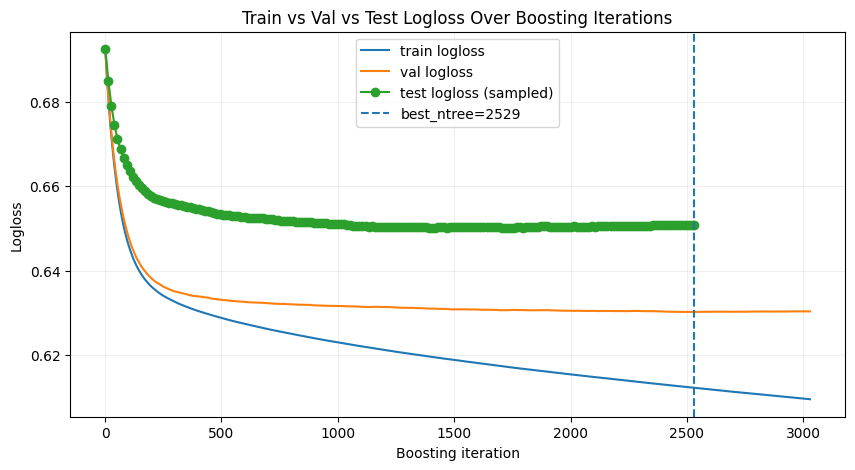

Saved XGBoost booster bundle to best_model_xgb.pkl


In [196]:
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

# ============================================================
# Helpers
# ============================================================

def loader_to_numpy(loader):
    """Flatten a torch DataLoader into numpy arrays (order depends on loader shuffle!)."""
    X_list, y_list = [], []
    for xb, yb in loader:
        X_list.append(xb.numpy())
        y_list.append(yb.numpy())
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y


def predict_probs_booster(booster: xgb.Booster, X: np.ndarray, best_ntree: int) -> np.ndarray:
    """Predict probabilities from a native xgboost Booster (version-safe)."""
    dmat = xgb.DMatrix(X)
    try:
        probs = booster.predict(dmat, iteration_range=(0, best_ntree))
    except TypeError:
        probs = booster.predict(dmat, ntree_limit=best_ntree)
    return probs.astype(np.float32)


def buy_metrics(y_true, probs, threshold: float):
    """Compute confusion + accuracy + P(success | BUY)."""
    probs = np.asarray(probs).ravel()
    y_true = np.asarray(y_true).ravel().astype(np.int64)
    pred = (probs >= threshold).astype(np.int64)

    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())

    total = max(1, len(y_true))
    acc = 100.0 * (tp + tn) / total

    buy_total = max(1, tp + fp)
    buy_success = 100.0 * tp / buy_total

    return {
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "acc": acc,
        "buy_success": buy_success
    }


def evaluate_and_save_test(
    booster: xgb.Booster,
    best_ntree: int,
    X_test: np.ndarray,
    y_test: np.ndarray,
    prob_threshold: float,
    save_csv: str = "test_predictions_full.csv",
    test_tickers: list = None,
    pct_changes: list = None,
):
    """Run full test eval, save predictions CSV, and plot charts."""
    probs = predict_probs_booster(booster, X_test, best_ntree)
    pred = (probs >= prob_threshold).astype(np.int64)
    ytrue = y_test.astype(np.int64)
    correct = (pred == ytrue)

    df = pd.DataFrame({
        "idx": np.arange(len(ytrue), dtype=np.int64),
        "prob_buy": probs.astype(np.float32),
        "pred": pred,
        "actual": ytrue,
        "correct": correct,
        "decision": np.where(pred == 1, "BUY", "NO-BUY"),
        "actual_label": np.where(ytrue == 1, "BUY", "NO-BUY"),
    })

    if test_tickers is not None and len(test_tickers) == len(df):
        df["ticker"] = test_tickers
    if pct_changes is not None and len(pct_changes) == len(df):
        df["pct_change"] = pct_changes

    df.to_csv(save_csv, index=False)
    print(f"Saved full test predictions to: {save_csv}")

    stats = buy_metrics(ytrue, probs, prob_threshold)
    tp, fp, tn, fn = stats["tp"], stats["fp"], stats["tn"], stats["fn"]
    acc = stats["acc"]
    pct_buy_success = stats["buy_success"]

    print(f">>>>>>>>> Percentage of successful BUYs: {pct_buy_success:.2f}% <<<<<<<<<<")

    summary = pd.DataFrame({
        "metric": [
            "total",
            "accuracy_%",
            "successful_BUY(TP)",
            "failed_BUY(FP)",
            "successful_NO_BUY(TN)",
            "failed_NO_BUY(FN)",
        ],
        "value": [len(ytrue), acc, tp, fp, tn, fn],
    })
    display(summary)

    total = max(1, len(ytrue))
    pct_tp_all = 100.0 * tp / total
    pct_fp_all = 100.0 * fp / total
    pct_tn_all = 100.0 * tn / total
    pct_fn_all = 100.0 * fn / total

    buy_total = max(1, tp + fp)
    pct_buy_success = 100.0 * tp / buy_total
    pct_buy_fail = 100.0 * fp / buy_total

    nobuy_total = max(1, tn + fn)
    pct_nobuy_success = 100.0 * tn / nobuy_total
    pct_nobuy_fail = 100.0 * fn / nobuy_total

    summary_pct = pd.DataFrame({
        "category": [
            "BUY_success_TP",
            "BUY_fail_FP",
            "NO_BUY_success_TN",
            "NO_BUY_fail_FN",
        ],
        "count": [tp, fp, tn, fn],
        "percent_of_all_%": [pct_tp_all, pct_fp_all, pct_tn_all, pct_fn_all],
        "percent_given_decision_%": [
            pct_buy_success,
            pct_buy_fail,
            pct_nobuy_success,
            pct_nobuy_fail,
        ],
    })
    display(summary_pct)

    # Chart 1: BUY vs NO-BUY (stacked success/fail)
    labels = ["BUY", "NO-BUY"]
    success = np.array([tp, tn], dtype=np.int64)
    fail    = np.array([fp, fn], dtype=np.int64)
    x = np.arange(len(labels))

    plt.figure(figsize=(7, 4))
    plt.bar(x, success, label="successful")
    plt.bar(x, fail, bottom=success, label="failed")
    plt.xticks(x, labels)
    plt.ylabel("count")
    plt.title(f"Test decisions @ thr={prob_threshold} | acc={acc:.2f}% | N={len(ytrue)}")
    plt.grid(True, alpha=0.2, axis="y")
    plt.legend()
    plt.show()

    # Chart 2: 4-way outcomes
    four_labels = ["BUY success (TP)", "BUY fail (FP)", "NO-BUY success (TN)", "NO-BUY fail (FN)"]
    four_counts = [tp, fp, tn, fn]
    x2 = np.arange(len(four_labels))

    plt.figure(figsize=(9, 4))
    plt.bar(x2, four_counts)
    plt.xticks(x2, four_labels, rotation=20, ha="right")
    plt.ylabel("count")
    plt.title(f"BUY / NO-BUY outcomes @ thr={prob_threshold} | N={len(ytrue)}")
    plt.grid(True, alpha=0.2, axis="y")

    for i, c in enumerate(four_counts):
        plt.text(i, c + max(1, len(ytrue)) * 0.01, str(c), ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    return df, summary, summary_pct


def compute_logloss_curve_over_iters(
    booster: xgb.Booster,
    X: np.ndarray,
    y: np.ndarray,
    iters: np.ndarray,
) -> np.ndarray:
    """Compute logloss at a set of iteration counts (post-training)."""
    dmat = xgb.DMatrix(X)
    y = y.astype(np.int64)
    out = []
    for k in iters:
        try:
            p = booster.predict(dmat, iteration_range=(0, int(k)))
        except TypeError:
            p = booster.predict(dmat, ntree_limit=int(k))
        out.append(log_loss(y, p))
    return np.asarray(out, dtype=np.float64)


# ============================================================
# 1) Build arrays from loaders (already scaled in your pipeline)
# NOTE: val_loader/test_loader should be shuffle=False to preserve order.
# ============================================================

X_train, y_train = loader_to_numpy(train_loader)
X_val,   y_val   = loader_to_numpy(val_loader)
X_test,  y_test  = loader_to_numpy(test_loader)

print(f"Train: {X_train.shape} pos={int((y_train==1).sum())} neg={int((y_train==0).sum())}")
print(f"Val:   {X_val.shape}   pos={int((y_val==1).sum())} neg={int((y_val==0).sum())}")
print(f"Test:  {X_test.shape}  pos={int((y_test==1).sum())} neg={int((y_test==0).sum())}")

# class imbalance
num_pos = float((y_train == 1).sum())
num_neg = float((y_train == 0).sum())
scale_pos_weight = num_neg / max(1.0, num_pos)
print(f"scale_pos_weight (neg/pos) = {scale_pos_weight:.4f}")

# ============================================================
# 2) Train XGBoost (native API) with early stopping + LOGLOSS CURVES
# ============================================================

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)

params = {
    "max_depth": 3,
    "eta": 0.01, # LR 
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "alpha": 3.0,
    "tree_method": "hist",
    "scale_pos_weight": scale_pos_weight,
    "lambda" : 2.0

}

PATIENCE = 100
num_boost_round = 10000 # max rounds
es_rounds = max(5, PATIENCE * 5)  # e.g. 15

evals_result = {}  # <-- collect per-iteration train/val metrics

print(f"Training with early stopping: rounds={num_boost_round}, early_stopping_rounds={es_rounds}")
booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtrain, "train"), (dval, "val")],  # keep val LAST so early stopping uses val
    early_stopping_rounds=es_rounds,
    evals_result=evals_result,
    verbose_eval=True,
)

best_ntree = int(booster.best_iteration + 1) if booster.best_iteration is not None else num_boost_round
print(f"Best iteration used: {best_ntree}")

# quick train/val logloss at best_ntree
probs_train = predict_probs_booster(booster, X_train, best_ntree)
probs_val   = predict_probs_booster(booster, X_val,   best_ntree)

print(f"Train logloss: {log_loss(y_train, probs_train):.6f}")
print(f"Val   logloss: {log_loss(y_val,   probs_val):.6f}")

train_stats = buy_metrics(y_train, probs_train, BUY_THRESHOLD)
val_stats   = buy_metrics(y_val,   probs_val,   BUY_THRESHOLD)

print(f"Train: acc={train_stats['acc']:.2f}% | P(success|BUY)={train_stats['buy_success']:.2f}% "
      f"| TP={train_stats['tp']} FP={train_stats['fp']} TN={train_stats['tn']} FN={train_stats['fn']}")
print(f"Val:   acc={val_stats['acc']:.2f}% | P(success|BUY)={val_stats['buy_success']:.2f}% "
      f"| TP={val_stats['tp']} FP={val_stats['fp']} TN={val_stats['tn']} FN={val_stats['fn']}")

# ============================================================
# 2b) NEW: Plot Train / Val / Test logloss as training progresses
#   - Train/Val from evals_result (free)
#   - Test computed post-training (sampled to keep it fast)
# ============================================================

train_ll = np.asarray(evals_result.get("train", {}).get("logloss", []), dtype=np.float64)
val_ll   = np.asarray(evals_result.get("val", {}).get("logloss", []),   dtype=np.float64)

iters_full = np.arange(1, len(train_ll) + 1)

# Sample test curve to avoid O(num_rounds * N_test) being too heavy
max_points = 200
step = max(1, int(np.ceil(best_ntree / max_points)))
iters_test = np.arange(1, best_ntree + 1, step)
if iters_test[-1] != best_ntree:
    iters_test = np.append(iters_test, best_ntree)

test_ll = compute_logloss_curve_over_iters(booster, X_test, y_test, iters_test)

plt.figure(figsize=(10, 5))
if len(train_ll) > 0:
    plt.plot(iters_full, train_ll, label="train logloss")
if len(val_ll) > 0:
    plt.plot(iters_full, val_ll, label="val logloss")
plt.plot(iters_test, test_ll, marker="o", linestyle="-", label="test logloss (sampled)")

plt.axvline(best_ntree, linestyle="--", label=f"best_ntree={best_ntree}")
plt.xlabel("Boosting iteration")
plt.ylabel("Logloss")
plt.title("Train vs Val vs Test Logloss Over Boosting Iterations")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# ============================================================
# 3) Save bundle (THIS is why later you must NOT call predict_proba)
# ============================================================

bundle = {"booster": booster, "best_ntree": best_ntree}
joblib.dump(bundle, "best_model_xgb.pkl")
print("Saved XGBoost booster bundle to best_model_xgb.pkl")


### Evaluate on Test Data 

Saved full test predictions to: test_predictions_full.csv
>>>>>>>>> Percentage of successful BUYs: 69.12% <<<<<<<<<<


,metric,value
0,total,9979.000000
1,accuracy_%,60.426896
2,successful_BUY(TP),4000.000000
3,failed_BUY(FP),1787.000000
4,successful_NO_BUY(TN),2030.000000
5,failed_NO_BUY(FN),2162.000000


,category,count,percent_of_all_%,percent_given_decision_%
0,BUY_success_TP,4000,40.084177,69.120442
1,BUY_fail_FP,1787,17.907606,30.879558
2,NO_BUY_success_TN,2030,20.342720,48.425573
3,NO_BUY_fail_FN,2162,21.665498,51.574427


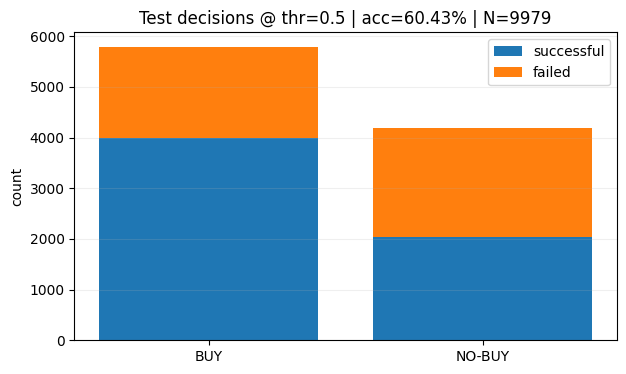

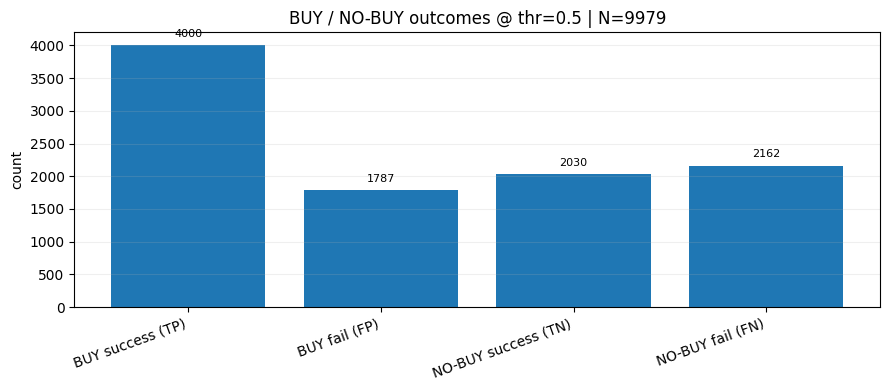

In [197]:
# ============================================================
# 4) Evaluate on test + save predictions + charts (FIXED)
#   - supports new index keys: test_start (preferred), val_cut (legacy)
#   - aligns pct_change by cached decision dates (no iloc misalignment)
# ============================================================

import pickle
with open(index_path, "rb") as f:
    index = pickle.load(f)

test_tickers = []
pct_changes  = []

for entry in index:
    data = np.load(entry["cache_file"])
    ticker = entry["ticker"]

    # New leakage-safe key is "test_start". Keep backward compat with "val_cut".
    test_start = entry.get("test_start", entry.get("val_cut", None))
    if test_start is None:
        raise KeyError(f"Index entry for {ticker} missing both 'test_start' and 'val_cut'.")

    test_start = int(test_start)

    y_full = data["y"]
    dates_full = data.get("dates", None)

    n_total = int(len(y_full))
    n_test = n_total - test_start
    if n_test <= 0:
        continue

    test_tickers.extend([ticker] * n_test)

    # ----- pct_change aligned by DATE (preferred) -----
    # pct_change here = (Close - Open) / Open * 100 for the same decision date.
    # If you want a different return definition, change it here.
    if dates_full is None:
        # No dates stored -> can't align safely; fill NaNs
        pct_changes.extend([np.nan] * n_test)
        continue

    test_dates = pd.to_datetime(dates_full[test_start:]).tz_localize(None)

    csv_path = stocks_dir / f"{ticker}.csv"
    try:
        df_csv = pd.read_csv(csv_path)
        if "Date" not in df_csv.columns:
            pct_changes.extend([np.nan] * n_test)
            continue

        df_csv["Date"] = pd.to_datetime(df_csv["Date"], errors="coerce")
        df_csv = df_csv.dropna(subset=["Date"]).sort_values("Date")
        df_csv = df_csv.set_index("Date")
        df_csv = df_csv[~df_csv.index.duplicated(keep="last")]

        # Reindex to the cached feature/label decision dates
        sub = df_csv.reindex(test_dates)

        # Ensure numeric
        sub["Open"]  = pd.to_numeric(sub.get("Open"), errors="coerce")
        sub["Close"] = pd.to_numeric(sub.get("Close"), errors="coerce")

        pct = ((sub["Close"] - sub["Open"]) / sub["Open"]) * 100.0
        pct = pct.to_numpy(dtype=np.float64)

        # Make sure we add exactly n_test values
        if len(pct) != n_test:
            # pad/truncate defensively
            if len(pct) < n_test:
                pct = np.concatenate([pct, np.full(n_test - len(pct), np.nan)])
            else:
                pct = pct[:n_test]

        pct_changes.extend(pct.tolist())

    except Exception:
        pct_changes.extend([np.nan] * n_test)

# Sanity: these should match X_test length
assert len(test_tickers) == len(X_test), f"test_tickers len mismatch: {len(test_tickers)} vs X_test {len(X_test)}"
assert len(pct_changes)  == len(X_test), f"pct_changes len mismatch: {len(pct_changes)} vs X_test {len(X_test)}"

df_test_preds, df_test_summary, df_test_summary_pct = evaluate_and_save_test(
    booster=booster,
    best_ntree=best_ntree,
    X_test=X_test,
    y_test=y_test,
    prob_threshold=BUY_THRESHOLD,
    save_csv="test_predictions_full.csv",
    test_tickers=test_tickers,
    pct_changes=pct_changes,
)

In [198]:
'''
# ============================================================
# Feature Importance Analysis
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ====== CONFIGURATION ======
TOP_N_FEATURES = 5  # Change this to 10, 20, 50, 100, or any number you want
# ===========================

# Get feature importance from the trained booster
importance_dict = booster.get_score(importance_type='gain')

# Map feature indices to feature names
feature_importance = []
for feature_name, importance_value in importance_dict.items():
    # feature_name is like 'f0', 'f1', etc.
    feature_idx = int(feature_name[1:])
    if feature_idx < len(FEATURE_NAMES):
        feature_importance.append({
            'feature': FEATURE_NAMES[feature_idx],
            'importance': importance_value
        })

# Create DataFrame and sort by importance
df_importance = pd.DataFrame(feature_importance)
df_importance = df_importance.sort_values('importance', ascending=False)

# Save to CSV
df_importance.to_csv('feature_importance_by_gain.csv', index=False)
print(f"✓ Saved feature importance by gain to: feature_importance_by_gain.csv")

print(f"\nTop {TOP_N_FEATURES} Most Important Features (by Gain):")
print("=" * 80)
display(df_importance.head(TOP_N_FEATURES))

# Calculate dynamic figure size based on number of features
fig_height = max(8, TOP_N_FEATURES * 0.4)  # 0.4 inches per feature, minimum 8 inches
font_size = max(6, min(10, 200 / TOP_N_FEATURES))  # Dynamic font size based on count

# Plot top N features
plt.figure(figsize=(14, fig_height))
top_features = df_importance.head(TOP_N_FEATURES)
plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'].values, fontsize=font_size)
plt.xlabel('Importance (Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {TOP_N_FEATURES} Most Important Features for Training', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Additional importance type: weight (number of times feature is used)
importance_weight_dict = booster.get_score(importance_type='weight')
feature_importance_weight = []
for feature_name, weight_value in importance_weight_dict.items():
    feature_idx = int(feature_name[1:])
    if feature_idx < len(FEATURE_NAMES):
        feature_importance_weight.append({
            'feature': FEATURE_NAMES[feature_idx],
            'weight': weight_value
        })

df_importance_weight = pd.DataFrame(feature_importance_weight)
df_importance_weight = df_importance_weight.sort_values('weight', ascending=False)

# Save to CSV
df_importance_weight.to_csv('feature_importance_by_weight.csv', index=False)
print(f"✓ Saved feature importance by weight to: feature_importance_by_weight.csv")

print(f"\nTop {TOP_N_FEATURES} Most Frequently Used Features (by Weight):")
print("=" * 80)
display(df_importance_weight.head(TOP_N_FEATURES))

# Plot top N features by weight
plt.figure(figsize=(14, fig_height))
top_features_weight = df_importance_weight.head(TOP_N_FEATURES)
plt.barh(range(len(top_features_weight)), top_features_weight['weight'].values, color='coral')
plt.yticks(range(len(top_features_weight)), top_features_weight['feature'].values, fontsize=font_size)
plt.xlabel('Weight (Frequency)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {TOP_N_FEATURES} Most Frequently Used Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Merge both importance types
df_combined = df_importance.merge(df_importance_weight, on='feature', how='outer').fillna(0)
df_combined['importance_normalized'] = df_combined['importance'] / df_combined['importance'].max()
df_combined['weight_normalized'] = df_combined['weight'] / df_combined['weight'].max()

# Save combined feature importance to CSV
df_combined_sorted = df_combined.sort_values('importance', ascending=False)
df_combined_sorted.to_csv('feature_importance_combined.csv', index=False)
print(f"✓ Saved combined feature importance to: feature_importance_combined.csv")

# Plot comparison of top N features by gain vs weight side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, fig_height))

top_by_gain = df_combined.nlargest(TOP_N_FEATURES, 'importance')

ax1.barh(range(len(top_by_gain)), top_by_gain['importance'].values, color='steelblue')
ax1.set_yticks(range(len(top_by_gain)))
ax1.set_yticklabels(top_by_gain['feature'].values, fontsize=font_size)
ax1.set_xlabel('Importance (Gain)', fontsize=12)
ax1.set_title(f'Top {TOP_N_FEATURES} Features by Gain', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

ax2.barh(range(len(top_by_gain)), top_by_gain['weight'].values, color='coral')
ax2.set_yticks(range(len(top_by_gain)))
ax2.set_yticklabels(top_by_gain['feature'].values, fontsize=font_size)
ax2.set_xlabel('Weight (Frequency)', fontsize=12)
ax2.set_title(f'Top {TOP_N_FEATURES} Features by Weight', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nFeature Importance Summary:")
print(f"Total features used: {len(df_importance)}")
print(f"Total features available: {len(FEATURE_NAMES)}")
print(f"Percentage of features used: {100 * len(df_importance) / len(FEATURE_NAMES):.2f}%")
print(f"\nTop 10 features by gain:")
for i, row in df_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.2f}")
'''

'\n# ============================================================\n# Feature Importance Analysis\n# ============================================================\n\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n# ====== CONFIGURATION ======\nTOP_N_FEATURES = 5  # Change this to 10, 20, 50, 100, or any number you want\n# ===========================\n\n# Get feature importance from the trained booster\nimportance_dict = booster.get_score(importance_type=\'gain\')\n\n# Map feature indices to feature names\nfeature_importance = []\nfor feature_name, importance_value in importance_dict.items():\n    # feature_name is like \'f0\', \'f1\', etc.\n    feature_idx = int(feature_name[1:])\n    if feature_idx < len(FEATURE_NAMES):\n        feature_importance.append({\n            \'feature\': FEATURE_NAMES[feature_idx],\n            \'importance\': importance_value\n        })\n\n# Create DataFrame and sort by importance\ndf_importance = pd.DataFrame(feature_importance)\ndf_importance = d

# Tune Buy Threthold

TUNING BUY_THRESHOLD ON VALIDATION SET

🎯 OPTIMAL THRESHOLD: 0.840
   Expected Value per Trade: 0.0081 (0.81%)

METRICS AT OPTIMAL THRESHOLD (0.840):
--------------------------------------------------------------------------------
  Trades per day:           9.73
  % BUY (out of all samples): 1.12%
  Win rate (TP hit %):      91.10%
  Average win:              0.90%
  Average loss:             -0.10%
  Expected value per trade: 0.81%
  P(success | BUY) after costs: 91.10%
  Total trades (val set):   292
  True Positives (TP):      266
  False Positives (FP):     26

✓ Saved threshold tuning results to: threshold_tuning_results.csv


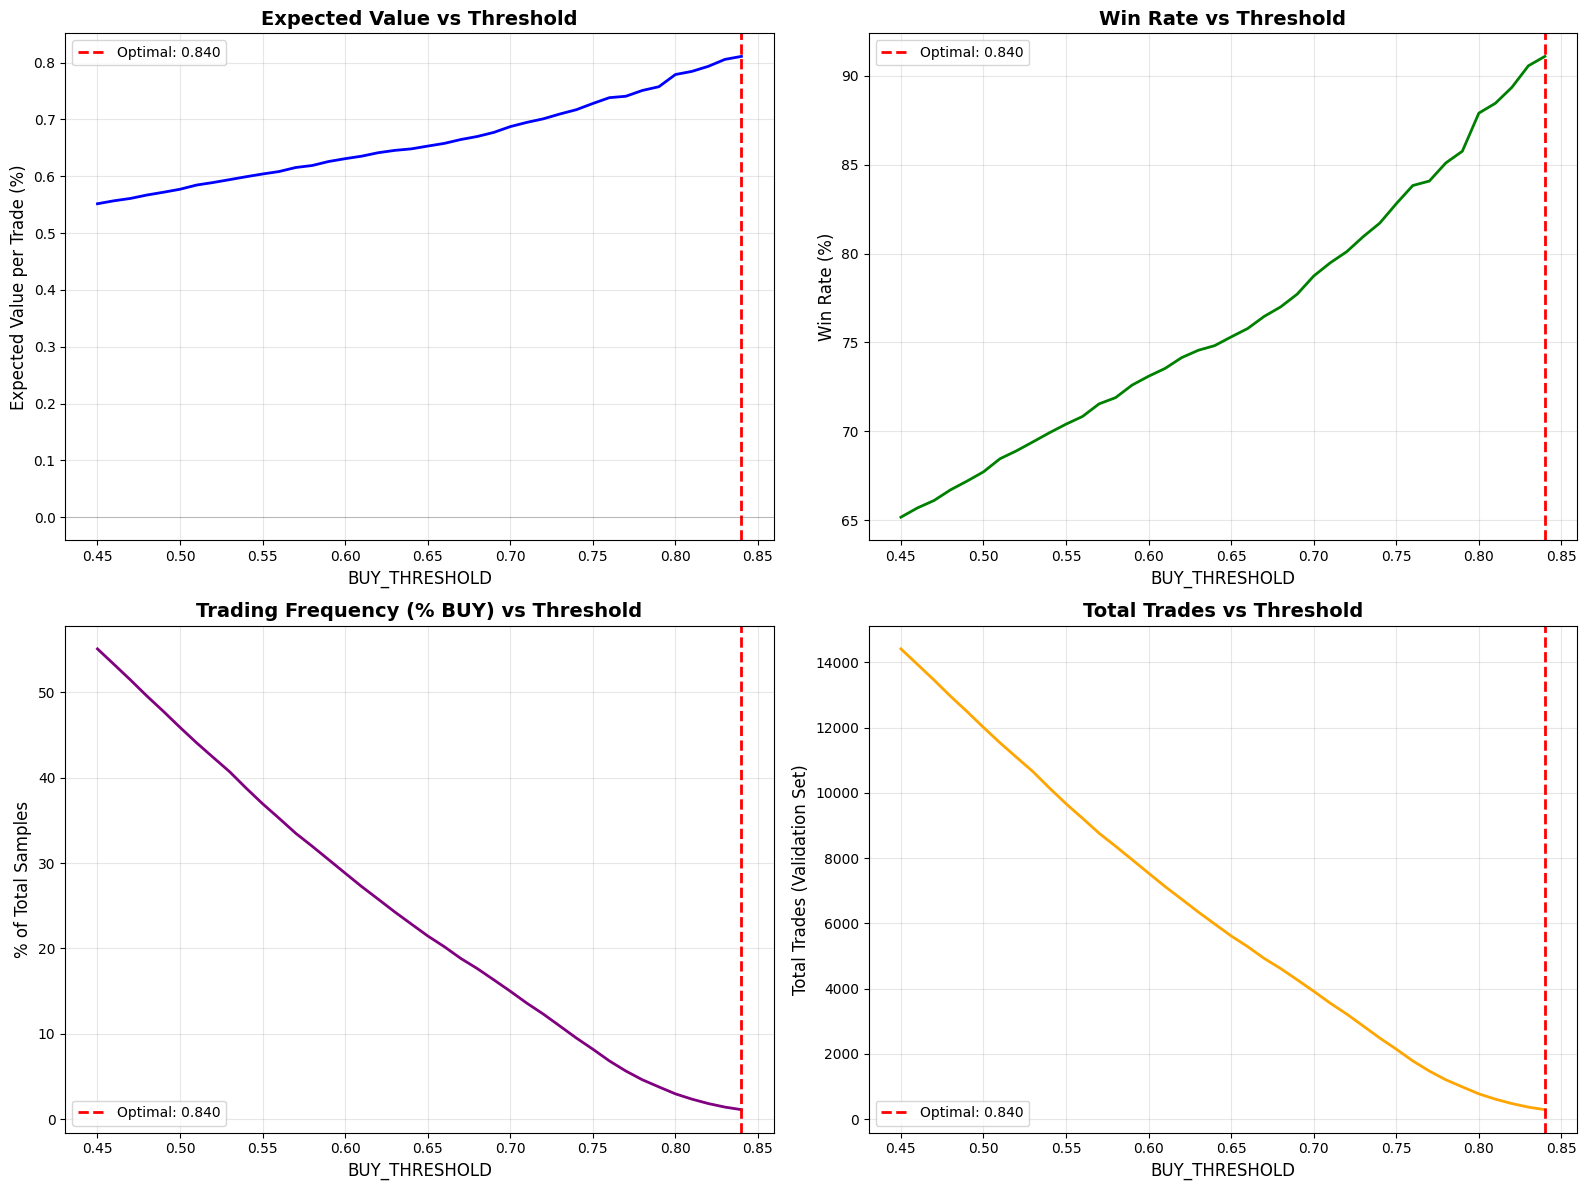


COMPREHENSIVE THRESHOLD ANALYSIS

Top 10 Thresholds by Expected Value:
✓ Saved top 10 thresholds to: top_10_thresholds_by_ev.csv



,threshold,trades_per_day,buy_%,win_rate_%,total_trades,ev_per_trade_%
39,0.84,9.733333,1.115952,91.095890,292,0.810959
38,0.83,12.366667,1.417871,90.566038,371,0.805660
37,0.82,15.966667,1.830620,89.352818,479,0.793528
36,0.81,20.500000,2.350378,88.455285,615,0.784553
35,0.80,25.900000,2.969502,87.902188,777,0.779022
34,0.79,33.000000,3.783536,85.757576,990,0.757576
33,0.78,40.266667,4.616678,85.099338,1208,0.750993
32,0.77,49.200000,5.640908,84.078591,1476,0.740786
31,0.76,59.566667,6.829473,83.827644,1787,0.738276
30,0.75,71.533333,8.201483,82.805219,2146,0.728052



💡 RECOMMENDATION: Update BUY_THRESHOLD to 0.840 for optimal performance


In [199]:
# ============================================================
# Tune BUY_THRESHOLD on Validation Set
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("TUNING BUY_THRESHOLD ON VALIDATION SET")
print("=" * 80)

# Get predictions on validation set
probs_val_tune = predict_probs_booster(booster, X_val, best_ntree)

# Define cost model (based on your PROFIT_THRESHOLD and STOP_LOSS_THRESHOLD)
# Assuming typical trading costs and slippage
TRADING_COST = 0.001  # 0.1% per round trip (buy + sell)

# Test different thresholds
threshold_values = np.arange(0.45, 0.85, 0.01)
results = []

for threshold in threshold_values:
    pred = (probs_val_tune >= threshold).astype(np.int64)
    
    # Count trades and outcomes
    tp = int(((pred == 1) & (y_val == 1)).sum())  # True Positive (BUY and profitable)
    fp = int(((pred == 1) & (y_val == 0)).sum())  # False Positive (BUY but not profitable)
    
    total_trades = tp + fp
    
    if total_trades == 0:
        continue
        
    win_rate = 100.0 * tp / total_trades
    
    # Calculate expected returns
    # When TP: we hit profit target = PROFIT_THRESHOLD gain - costs
    # When FP: we don't hit profit (could hit stop loss or just no profit)
    # For simplicity, assume FP means 0% return on average after costs
    
    avg_win = PROFIT_THRESHOLD - TRADING_COST  # profit minus costs
    avg_loss = -TRADING_COST  # just costs, no gain
    
    # Expected value per trade
    ev_per_trade = (tp / total_trades) * avg_win + (fp / total_trades) * avg_loss
    
    # Trades per day (assuming validation set spans multiple days)
    # We need to know how many days in validation set
    # Approximate: if val set is ~15% of data, and total data is from July to now (~6-7 months)
    # That's roughly 180-210 days total, so val set is ~27-31 days
    # For safer estimate, let's use 30 days
    val_days = 30  # approximate
    trades_per_day = total_trades / val_days
    
    # Calculate % of BUY trades out of all samples
    total_samples = len(y_val)
    buy_pct = 100.0 * total_trades / total_samples
    
    results.append({
        'threshold': threshold,
        'total_trades': total_trades,
        'trades_per_day': trades_per_day,
        'buy_%': buy_pct,
        'win_rate_%': win_rate,
        'tp': tp,
        'fp': fp,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'ev_per_trade': ev_per_trade,
        'p_success_after_costs': win_rate  # Win rate already accounts for hitting profit target
    })

df_threshold_tune = pd.DataFrame(results)

# Find optimal threshold (maximize EV per trade)
optimal_idx = df_threshold_tune['ev_per_trade'].idxmax()
optimal_threshold = df_threshold_tune.loc[optimal_idx, 'threshold']
optimal_ev = df_threshold_tune.loc[optimal_idx, 'ev_per_trade']

print(f"\n🎯 OPTIMAL THRESHOLD: {optimal_threshold:.3f}")
print(f"   Expected Value per Trade: {optimal_ev:.4f} ({optimal_ev*100:.2f}%)")
print("=" * 80)

# Display metrics at optimal threshold
optimal_row = df_threshold_tune.loc[optimal_idx]
print(f"\nMETRICS AT OPTIMAL THRESHOLD ({optimal_threshold:.3f}):")
print("-" * 80)
print(f"  Trades per day:           {optimal_row['trades_per_day']:.2f}")
print(f"  % BUY (out of all samples): {optimal_row['buy_%']:.2f}%")
print(f"  Win rate (TP hit %):      {optimal_row['win_rate_%']:.2f}%")
print(f"  Average win:              {optimal_row['avg_win']*100:.2f}%")
print(f"  Average loss:             {optimal_row['avg_loss']*100:.2f}%")
print(f"  Expected value per trade: {optimal_row['ev_per_trade']*100:.2f}%")
print(f"  P(success | BUY) after costs: {optimal_row['p_success_after_costs']:.2f}%")
print(f"  Total trades (val set):   {optimal_row['total_trades']:.0f}")
print(f"  True Positives (TP):      {optimal_row['tp']:.0f}")
print(f"  False Positives (FP):     {optimal_row['fp']:.0f}")
print("=" * 80)

# Save tuning results to CSV
df_threshold_tune.to_csv('threshold_tuning_results.csv', index=False)
print(f"\n✓ Saved threshold tuning results to: threshold_tuning_results.csv")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: EV per trade vs threshold
ax1 = axes[0, 0]
ax1.plot(df_threshold_tune['threshold'], df_threshold_tune['ev_per_trade']*100, 'b-', linewidth=2)
ax1.axvline(optimal_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal: {optimal_threshold:.3f}')
ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax1.set_xlabel('BUY_THRESHOLD', fontsize=12)
ax1.set_ylabel('Expected Value per Trade (%)', fontsize=12)
ax1.set_title('Expected Value vs Threshold', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Win rate vs threshold
ax2 = axes[0, 1]
ax2.plot(df_threshold_tune['threshold'], df_threshold_tune['win_rate_%'], 'g-', linewidth=2)
ax2.axvline(optimal_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal: {optimal_threshold:.3f}')
ax2.set_xlabel('BUY_THRESHOLD', fontsize=12)
ax2.set_ylabel('Win Rate (%)', fontsize=12)
ax2.set_title('Win Rate vs Threshold', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Trading frequency as % of all samples vs threshold
ax3 = axes[1, 0]
ax3.plot(df_threshold_tune['threshold'], df_threshold_tune['buy_%'], 'purple', linewidth=2)
ax3.axvline(optimal_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal: {optimal_threshold:.3f}')
ax3.set_xlabel('BUY_THRESHOLD', fontsize=12)
ax3.set_ylabel('% of Total Samples', fontsize=12)
ax3.set_title('Trading Frequency (% BUY) vs Threshold', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Total trades vs threshold
ax4 = axes[1, 1]
ax4.plot(df_threshold_tune['threshold'], df_threshold_tune['total_trades'], 'orange', linewidth=2)
ax4.axvline(optimal_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal: {optimal_threshold:.3f}')
ax4.set_xlabel('BUY_THRESHOLD', fontsize=12)
ax4.set_ylabel('Total Trades (Validation Set)', fontsize=12)
ax4.set_title('Total Trades vs Threshold', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Create comprehensive summary table
print("\n" + "=" * 80)
print("COMPREHENSIVE THRESHOLD ANALYSIS")
print("=" * 80)
print("\nTop 10 Thresholds by Expected Value:")
top_10_by_ev = df_threshold_tune.nlargest(10, 'ev_per_trade')[['threshold', 'trades_per_day', 'buy_%', 'win_rate_%', 'ev_per_trade', 'total_trades']]
top_10_by_ev['ev_per_trade_%'] = top_10_by_ev['ev_per_trade'] * 100
top_10_by_ev = top_10_by_ev.drop('ev_per_trade', axis=1)

# Save top 10 table to CSV
top_10_by_ev.to_csv('top_10_thresholds_by_ev.csv', index=False)
print(f"✓ Saved top 10 thresholds to: top_10_thresholds_by_ev.csv\n")

display(top_10_by_ev)

print("\n" + "=" * 80)
print(f"💡 RECOMMENDATION: Update BUY_THRESHOLD to {optimal_threshold:.3f} for optimal performance")
print("=" * 80)

# Eval Data Analysis

,Date,num_trades,pct_success,pct_fail,num_success,num_fail
0,2025-12-09,3,100.0,0.0,3,0
1,2025-12-16,1,100.0,0.0,1,0
2,2025-12-17,1,100.0,0.0,1,0
3,2025-12-18,3,100.0,0.0,3,0
4,2025-12-19,1,100.0,0.0,1,0
5,2025-12-24,1,100.0,0.0,1,0
6,2025-12-26,1,100.0,0.0,1,0
7,2025-12-29,4,100.0,0.0,4,0
8,2025-12-30,1,100.0,0.0,1,0
9,2025-12-31,1,100.0,0.0,1,0



Threshold: 0.900
Validation days (unique dates): 34
Total BUY trades in val: 32
Days with >=1 trade: 18
Overall P(success | BUY) on val @ thr=0.900: 100.00%


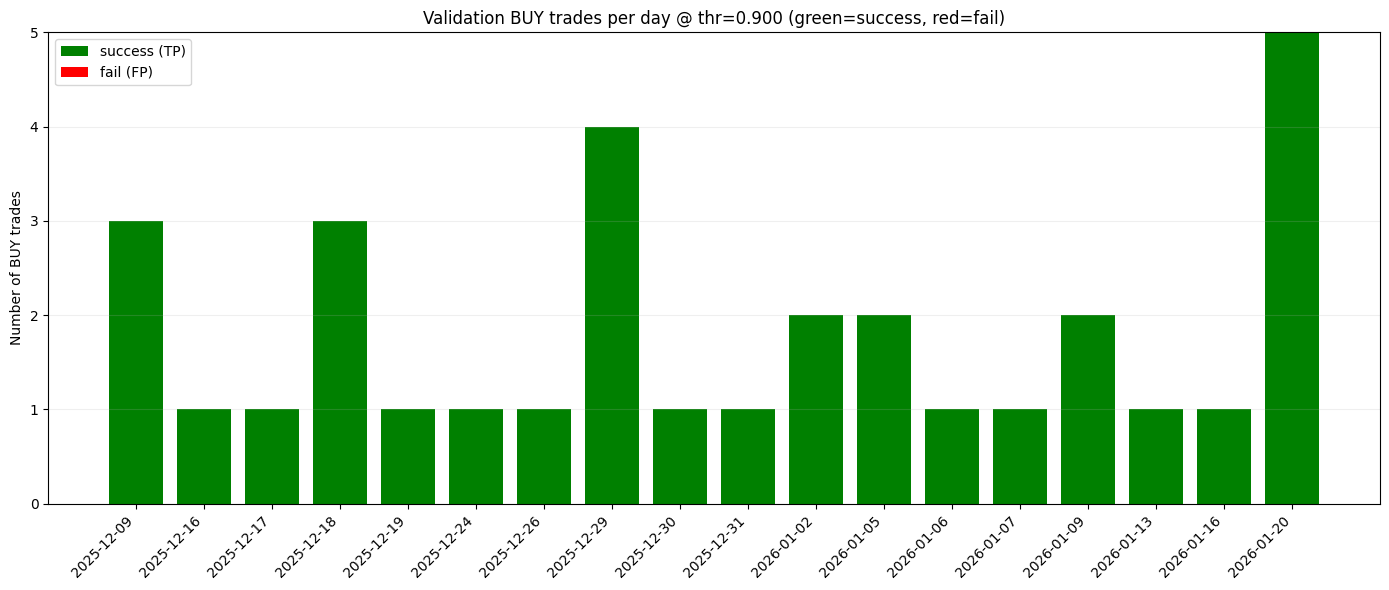

In [200]:
# ============================================================
# Trades-per-day table on VALIDATION set @ selected threshold
# Includes: num trades, % success, % fail
# Plot: green=success trades, red=fail trades (stacked)
# ============================================================

import numpy as np
import pandas as pd
import pickle
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
SELECTED_THRESHOLD = 0.9  # <-- set your threshold here (e.g. optimal_threshold)

# ----------------------------
# Load cache index + scaler
# ----------------------------
with open(index_path, "rb") as f:
    index = pickle.load(f)

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

# ----------------------------
# Load model bundle (booster + best_ntree)
# ----------------------------
bundle = joblib.load("best_model_xgb.pkl")
booster = bundle["booster"]
best_ntree = int(bundle["best_ntree"])

def predict_probs_booster(booster: xgb.Booster, X: np.ndarray, best_ntree: int) -> np.ndarray:
    """Predict probabilities from a native xgboost Booster (version-safe)."""
    dmat = xgb.DMatrix(X)
    try:
        probs = booster.predict(dmat, iteration_range=(0, best_ntree))
    except TypeError:
        probs = booster.predict(dmat, ntree_limit=best_ntree)
    return probs.astype(np.float32)

# ----------------------------
# Build validation predictions dataframe WITH DATES + TICKER
# ----------------------------
rows = []

for entry in index:
    data = np.load(entry["cache_file"])
    ticker = entry["ticker"]

    X_full = data["X"].astype(np.float32)
    y_full = data["y"].astype(np.float32)
    dates  = pd.to_datetime(data["dates"])

    val_start = int(entry["val_start"])
    val_end   = int(entry["val_end"])

    # Validation slice
    Xv = X_full[val_start:val_end]
    yv = y_full[val_start:val_end]
    dv = dates[val_start:val_end]

    if len(Xv) == 0:
        continue

    # Scale like training pipeline
    Xv_scaled = scaler.transform(Xv).astype(np.float32, copy=False)

    # Predict
    pv = predict_probs_booster(booster, Xv_scaled, best_ntree)

    rows.append(pd.DataFrame({
        "Date": dv,
        "ticker": ticker,
        "y_true": yv.astype(np.int8),
        "prob_buy": pv,
    }))

val_preds = pd.concat(rows, ignore_index=True)

# Normalize Date to pure date (no time)
val_preds["Date"] = pd.to_datetime(val_preds["Date"]).dt.normalize()

# ✅ Total number of validation days (unique dates in val across all tickers)
num_val_days = int(val_preds["Date"].nunique())

# Decision at threshold
val_preds["pred_buy"] = (val_preds["prob_buy"] >= SELECTED_THRESHOLD).astype(np.int8)

# Consider only executed trades (pred_buy == 1)
trades = val_preds[val_preds["pred_buy"] == 1].copy()

# success = label == 1, fail = label == 0
trades["is_success"] = (trades["y_true"] == 1).astype(np.int8)
trades["is_fail"]    = (trades["y_true"] == 0).astype(np.int8)

# ----------------------------
# ✅ Trades-per-day table with success/fail
# ----------------------------
daily = trades.groupby("Date").agg(
    num_trades=("pred_buy", "size"),
    num_success=("is_success", "sum"),
    num_fail=("is_fail", "sum"),
).reset_index().sort_values("Date")

daily["pct_success"] = np.where(daily["num_trades"] > 0, 100.0 * daily["num_success"] / daily["num_trades"], np.nan)
daily["pct_fail"]    = np.where(daily["num_trades"] > 0, 100.0 * daily["num_fail"] / daily["num_trades"], np.nan)

# Clean column order for display
daily_table = daily[["Date", "num_trades", "pct_success", "pct_fail", "num_success", "num_fail"]].copy()

display(daily_table)

print(f"\nThreshold: {SELECTED_THRESHOLD:.3f}")
print(f"Validation days (unique dates): {num_val_days}")
print(f"Total BUY trades in val: {int(daily['num_trades'].sum())}")
print(f"Days with >=1 trade: {len(daily)}")
print(f"Overall P(success | BUY) on val @ thr={SELECTED_THRESHOLD:.3f}: "
      f"{100.0 * daily['num_success'].sum() / max(1, daily['num_trades'].sum()):.2f}%")

# ----------------------------
# Plot: stacked bars (green=success, red=fail)
# ----------------------------
x_labels = daily["Date"].dt.strftime("%Y-%m-%d").to_list()
x = np.arange(len(x_labels))

plt.figure(figsize=(14, 6))
plt.bar(x, daily["num_success"].to_numpy(), color="green", label="success (TP)")
plt.bar(x, daily["num_fail"].to_numpy(), bottom=daily["num_success"].to_numpy(), color="red", label="fail (FP)")

plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Number of BUY trades")
plt.title(f"Validation BUY trades per day @ thr={SELECTED_THRESHOLD:.3f} (green=success, red=fail)")
plt.grid(True, alpha=0.2, axis="y")
plt.legend()
plt.tight_layout()
plt.show()


# Test Data Analysis

,Date,num_trades,pct_success,pct_fail,num_success,num_fail
0,2026-01-22,1,100.0,0.0,1,0
1,2026-01-23,1,100.0,0.0,1,0
2,2026-01-27,3,100.0,0.0,3,0
3,2026-01-30,2,100.0,0.0,2,0
4,2026-02-02,4,100.0,0.0,4,0
5,2026-02-03,1,100.0,0.0,1,0
6,2026-02-05,12,100.0,0.0,12,0



Threshold: 0.900
Test days (unique dates): 13
Total BUY trades in test: 24
Days with >=1 trade: 7
Overall P(success | BUY) on test @ thr=0.900: 100.00%


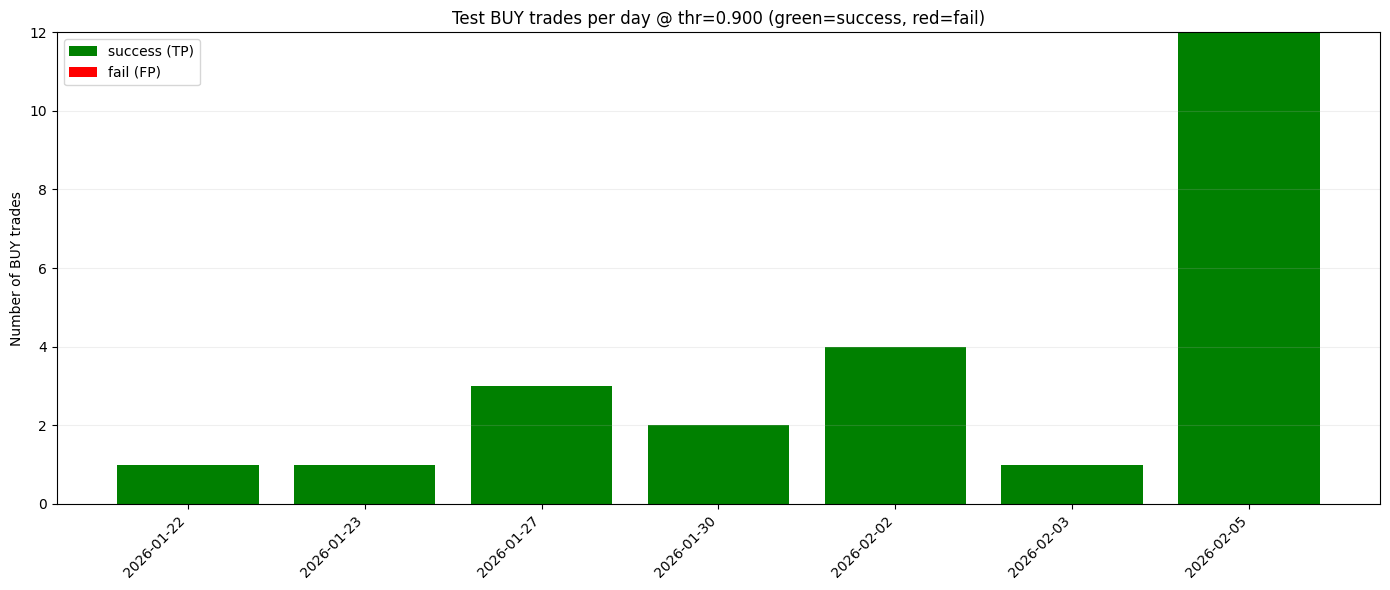

In [203]:
# ============================================================
# Trades-per-day table on TEST set @ selected threshold
# Includes: num trades, % success, % fail
# Plot: green=success trades, red=fail trades (stacked)
# ============================================================

import numpy as np
import pandas as pd
import pickle
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
SELECTED_THRESHOLD = 0.9  # <-- set your threshold here (e.g. optimal_threshold)

# ----------------------------
# Load cache index + scaler
# ----------------------------
with open(index_path, "rb") as f:
    index = pickle.load(f)

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

# ----------------------------
# Load model bundle (booster + best_ntree)
# ----------------------------
bundle = joblib.load("best_model_xgb.pkl")
booster = bundle["booster"]
best_ntree = int(bundle["best_ntree"])

def predict_probs_booster(booster: xgb.Booster, X: np.ndarray, best_ntree: int) -> np.ndarray:
    """Predict probabilities from a native xgboost Booster (version-safe)."""
    dmat = xgb.DMatrix(X)
    try:
        probs = booster.predict(dmat, iteration_range=(0, best_ntree))
    except TypeError:
        probs = booster.predict(dmat, ntree_limit=best_ntree)
    return probs.astype(np.float32)

# ----------------------------
# Build TEST predictions dataframe WITH DATES + TICKER
# ----------------------------
rows = []

for entry in index:
    data = np.load(entry["cache_file"])
    ticker = entry["ticker"]

    X_full = data["X"].astype(np.float32)
    y_full = data["y"].astype(np.float32)
    dates  = pd.to_datetime(data["dates"])

    test_start = int(entry["test_start"])  # <-- TEST split boundary

    # TEST slice
    Xt = X_full[test_start:]
    yt = y_full[test_start:]
    dt = dates[test_start:]

    if len(Xt) == 0:
        continue

    # Scale like training pipeline
    Xt_scaled = scaler.transform(Xt).astype(np.float32, copy=False)

    # Predict
    pt = predict_probs_booster(booster, Xt_scaled, best_ntree)

    rows.append(pd.DataFrame({
        "Date": dt,
        "ticker": ticker,
        "y_true": yt.astype(np.int8),
        "prob_buy": pt,
    }))

test_preds = pd.concat(rows, ignore_index=True)

# Normalize Date to pure date (no time)
test_preds["Date"] = pd.to_datetime(test_preds["Date"]).dt.normalize()

# ✅ Total number of TEST days (unique dates in test across all tickers)
num_test_days = int(test_preds["Date"].nunique())

# Decision at threshold
test_preds["pred_buy"] = (test_preds["prob_buy"] >= SELECTED_THRESHOLD).astype(np.int8)

# Consider only executed trades (pred_buy == 1)
trades = test_preds[test_preds["pred_buy"] == 1].copy()

# success = label == 1, fail = label == 0
trades["is_success"] = (trades["y_true"] == 1).astype(np.int8)
trades["is_fail"]    = (trades["y_true"] == 0).astype(np.int8)

# ----------------------------
# ✅ Trades-per-day table with success/fail
# ----------------------------
daily = trades.groupby("Date").agg(
    num_trades=("pred_buy", "size"),
    num_success=("is_success", "sum"),
    num_fail=("is_fail", "sum"),
).reset_index().sort_values("Date")

daily["pct_success"] = np.where(daily["num_trades"] > 0, 100.0 * daily["num_success"] / daily["num_trades"], np.nan)
daily["pct_fail"]    = np.where(daily["num_trades"] > 0, 100.0 * daily["num_fail"] / daily["num_trades"], np.nan)

# Clean column order for display
daily_table = daily[["Date", "num_trades", "pct_success", "pct_fail", "num_success", "num_fail"]].copy()

display(daily_table)

print(f"\nThreshold: {SELECTED_THRESHOLD:.3f}")
print(f"Test days (unique dates): {num_test_days}")
print(f"Total BUY trades in test: {int(daily['num_trades'].sum())}")
print(f"Days with >=1 trade: {len(daily)}")
print(f"Overall P(success | BUY) on test @ thr={SELECTED_THRESHOLD:.3f}: "
      f"{100.0 * daily['num_success'].sum() / max(1, daily['num_trades'].sum()):.2f}%")

# ----------------------------
# Plot: stacked bars (green=success, red=fail)
# ----------------------------
x_labels = daily["Date"].dt.strftime("%Y-%m-%d").to_list()
x = np.arange(len(x_labels))

plt.figure(figsize=(14, 6))
plt.bar(x, daily["num_success"].to_numpy(), color="green", label="success (TP)")
plt.bar(x, daily["num_fail"].to_numpy(), bottom=daily["num_success"].to_numpy(), color="red", label="fail (FP)")

plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Number of BUY trades")
plt.title(f"Test BUY trades per day @ thr={SELECTED_THRESHOLD:.3f} (green=success, red=fail)")
plt.grid(True, alpha=0.2, axis="y")
plt.legend()
plt.tight_layout()
plt.show()


In [202]:
# don't execute the next cells
raise KeyboardInterrupt

KeyboardInterrupt: 

# Real Life Test #3 :: using it to make a decision

In [204]:
# ============================================================
# Real Life Testing (#3): scan ALL tickers at START OF DAY with OPEN price
# and print BUY/NO BUY using XGBoost (native Booster bundle)
#
# SCENARIO: Use at market open when you have:
# - Today's opening price
# - All previous complete bars (yesterday's full OHLCV and earlier)
#
# REQUIREMENTS (already in your notebook):
# - TICKERS (list of tickers)
# - WINDOW (int)  e.g. 30
# - INTERVAL (str) e.g. "1d"
# - BUY_THRESHOLD (float) e.g. 0.7
# - best_model_xgb.pkl saved as {"booster": Booster, "best_ntree": int}
# - scaler.pkl exists at .feature_cache_forward_return_w{WINDOW}/scaler.pkl
# ============================================================

import time
import pickle
import numpy as np
import pandas as pd
import yfinance as yf
import joblib
import xgboost as xgb
from pathlib import Path
from zoneinfo import ZoneInfo

# ----------------------------
# CONFIG (using hyperparameters set at the top of the notebook)
# ----------------------------
PROB_THRESHOLD = BUY_THRESHOLD  # Use the BUY_THRESHOLD from config
LOOKBACK_DAYS  = max(WINDOW * 3, 180)  # Ensure enough lookback for window + warmup
CHUNK_SIZE     = 40
SLEEP_BETWEEN_CHUNKS = 0.5
INTERVAL = "1d"

# Display current hyperparameters being used
print(f"Using hyperparameters:")
print(f"  BUY_THRESHOLD:      {BUY_THRESHOLD}")
print(f"  PROFIT_THRESHOLD:   {PROFIT_THRESHOLD}")
print(f"  HORIZON_BARS:       {HORIZON_BARS}")
print(f"  WINDOW:             {WINDOW}")
print(f"  INTERVAL:           {INTERVAL}")
print(f"  LOOKBACK_DAYS:      {LOOKBACK_DAYS}")
print()

tz_market = ZoneInfo("America/New_York")

# For start-of-day trading: use today's date at market open time
# This ensures we get all previous complete bars (yesterday and before)
today_market = pd.Timestamp.now(tz_market).normalize()  # Today at 00:00
start_market  = today_market - pd.Timedelta(days=LOOKBACK_DAYS)
# IMPORTANT: To get data from today, you have to set end date to tomorrow!
end_market    = today_market + pd.Timedelta(days=1)  # Include today's data


def _to_naive_utc(ts: pd.Timestamp) -> pd.Timestamp:
    return ts.tz_convert("UTC").tz_localize(None) if ts.tz is not None else ts


start_naive_utc = _to_naive_utc(start_market)
end_naive_utc   = _to_naive_utc(end_market)


def predict_probs_booster(booster: xgb.Booster, X: np.ndarray, best_ntree: int) -> np.ndarray:
    """Predict probabilities from a native xgboost Booster (version-safe)."""
    dmat = xgb.DMatrix(X)
    try:
        probs = booster.predict(dmat, iteration_range=(0, best_ntree))
    except TypeError:
        probs = booster.predict(dmat, ntree_limit=best_ntree)
    return probs.astype(np.float32)


def _ema(s: pd.Series, span: int) -> pd.Series:
    return s.ewm(span=span, adjust=False, min_periods=span).mean()


def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))


def _true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    prev_close = close.shift(1)
    tr1 = (high - low).abs()
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    return pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)


def _atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr = _true_range(high, low, close)
    return tr.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()


def _macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = _ema(close, fast)
    ema_slow = _ema(close, slow)
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False, min_periods=signal).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist


def _stoch_k(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    ll = low.rolling(period, min_periods=period).min()
    hh = high.rolling(period, min_periods=period).max()
    denom = (hh - ll).replace(0.0, np.nan)
    return 100.0 * (close - ll) / denom


def _stoch_d(stoch_k: pd.Series, smooth: int = 3) -> pd.Series:
    return stoch_k.rolling(smooth, min_periods=smooth).mean()


def _cci(high: pd.Series, low: pd.Series, close: pd.Series, n: int = 20) -> pd.Series:
    tp = (high + low + close) / 3.0
    sma = tp.rolling(n, min_periods=n).mean()
    md = tp.rolling(n, min_periods=n).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
    return (tp - sma) / (0.015 * (md + 1e-12))


def _adx_dmi(high: pd.Series, low: pd.Series, close: pd.Series, n: int = 14):
    up_move   = high.diff()
    down_move = -low.diff()

    plus_dm  = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    prev_close = close.shift(1)
    tr = pd.concat(
    [
        (high - low).abs(),
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ],
    axis=1,
    ).max(axis=1)

    tr_smooth = tr.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    plus_dm_smooth  = pd.Series(plus_dm, index=high.index).ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    minus_dm_smooth = pd.Series(minus_dm, index=high.index).ewm(alpha=1/n, adjust=False, min_periods=n).mean()

    plus_di  = 100.0 * (plus_dm_smooth  / (tr_smooth + 1e-12))
    minus_di = 100.0 * (minus_dm_smooth / (tr_smooth + 1e-12))

    dx  = 100.0 * ((plus_di - minus_di).abs() / ((plus_di + minus_di) + 1e-12))
    adx = dx.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    return adx, plus_di, minus_di


def add_my_ta_features(df: pd.DataFrame) -> pd.DataFrame:
    """Trend/EMA/MACD/RSI/Stoch/CCI/ADX (causal)"""
    out = df.copy()
    c = out["Close"]
    h = out["High"]
    l = out["Low"]

    out["ema_10"] = _ema(c, 10)
    out["ema_20"] = _ema(c, 20)
    out["ema_50"] = _ema(c, 50)

    macd, macd_sig, macd_hist = _macd(c, 12, 26, 9)
    out["macd"] = macd
    out["macd_signal"] = macd_sig
    out["macd_hist"] = macd_hist

    out["rsi_14"] = _rsi(c, 14)

    stoch_k = _stoch_k(h, l, c, 14)
    out["stoch_k_14"] = stoch_k
    out["stoch_d_14"] = _stoch_d(stoch_k, 3)

    out["cci_20"] = _cci(h, l, c, 20)

    adx, plus_di, minus_di = _adx_dmi(h, l, c, 14)
    out["adx_14"] = adx
    out["plus_di_14"] = plus_di
    out["minus_di_14"] = minus_di

    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def build_model_features_from_df(df_upto: pd.DataFrame, window: int) -> pd.DataFrame:
    """
    Build the SAME engineered feature set as training (no labels).
    
    SCENARIO: We BUY at market OPEN, only knowing today's OPEN price.
    Features use only PREVIOUS day's complete OHLCV + today's OPEN.
    
    FOR PRODUCTION: Pass in historical data with complete bars PLUS today's row
    with ONLY Open filled (High, Low, Close, Volume can be NaN or last known values).
    
    Expects columns: Date, Open, High, Low, Close, Volume.
    Returns DataFrame with columns ["Date", <features + lags>].
    """
    if "Date" not in df_upto.columns:
        raise ValueError("build_model_features_from_df expects a 'Date' column.")

    df = df_upto.copy()

    # Normalize and sort by Date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    # Ensure numeric OHLCV
    for c in ["Open", "High", "Low", "Close", "Volume"]:
        if c not in df.columns:
            raise ValueError(f"Missing column '{c}' in df_upto for feature building.")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # For production: last row might only have Open filled
    # We need at least Open for all rows
    df = df.dropna(subset=["Open"]).reset_index(drop=True)

    if len(df) < max(window + 2, 2):
        return pd.DataFrame(columns=["Date"])

    # =========================
    # Features: Only use data available at market OPEN
    # - All historical (t-1, t-2, ...) complete OHLCV
    # - Current day (t): ONLY the Open price (no High, Low, Close, Volume)
    # =========================
    
    # SHIFT all OHLCV data by 1 period to represent "previous" complete bars
    # The current row now represents what we knew BEFORE today opened
    df["prev_Open"] = df["Open"].shift(1)
    df["prev_High"] = df["High"].shift(1)
    df["prev_Low"] = df["Low"].shift(1)
    df["prev_Close"] = df["Close"].shift(1)
    df["prev_Volume"] = df["Volume"].shift(1)
    
    # Today's open is known (no shift needed for features that use it)
    df["today_Open"] = df["Open"]
    
    # All calculations below use PREVIOUS day's OHLCV (shifted data)
    # This ensures we only use information available before today's open
    
    # Basic per-bar returns / range (using PREVIOUS close)
    df["logret_1"] = np.log(df["prev_Close"] / df["prev_Close"].shift(1))
    df["ret_co"] = (df["prev_Close"] / df["prev_Open"]) - 1.0
    df["range_hl"] = (df["prev_High"] - df["prev_Low"]) / df["prev_Close"]

    # Gap from previous close to today's open
    df["gap_prevclose_to_open"] = (df["today_Open"] / df["prev_Close"]) - 1.0
    
    # Relative previous OHLC to close before that (scale-free price levels)
    close_t2 = df["prev_Close"].shift(1)  # Close from t-2
    df["open_rel_prevclose"] = (df["prev_Open"] / close_t2) - 1.0
    df["high_rel_prevclose"] = (df["prev_High"] / close_t2) - 1.0
    df["low_rel_prevclose"] = (df["prev_Low"] / close_t2) - 1.0

    # Candle anatomy of PREVIOUS bar (normalized)
    body = df["prev_Close"] - df["prev_Open"]
    denom_close = df["prev_Close"].replace(0.0, np.nan)
    df["body_size"] = body / denom_close
    upper_raw = df["prev_High"] - pd.concat([df["prev_Open"], df["prev_Close"]], axis=1).max(axis=1)
    lower_raw = pd.concat([df["prev_Open"], df["prev_Close"]], axis=1).min(axis=1) - df["prev_Low"]
    df["upper_wick_norm"] = upper_raw / denom_close
    df["lower_wick_norm"] = lower_raw / denom_close
    range_raw = (df["prev_High"] - df["prev_Low"]).replace(0.0, np.nan)
    df["body_to_range"] = body.abs() / range_raw
    df["clv"] = ((df["prev_Close"] - df["prev_Low"]) - (df["prev_High"] - df["prev_Close"])) / range_raw

    # ATR-based volatility (using PREVIOUS bars)
    df["atr14"] = _atr(df["prev_High"], df["prev_Low"], df["prev_Close"], period=14)
    df["atr14_norm"] = df["atr14"] / denom_close
    df["atr14_impulse_60"] = df["atr14_norm"] / df["atr14_norm"].rolling(60, min_periods=60).mean()

    # Rolling returns / momentum (using PREVIOUS close prices)
    for win in (3, 6, 12):
        roll = df["logret_1"].rolling(win, min_periods=win).sum()
        df[f"logret_sum_{win}"] = roll
        df[f"logret_mean_{win}"] = roll / float(win)

    # Simple N-bar price slopes (using PREVIOUS close)
    for win in (3, 6, 12):
        df[f"slope_close_{win}"] = (df["prev_Close"] - df["prev_Close"].shift(win)) / float(win)

    # Distance to rolling highs/lows (using PREVIOUS close)
    roll_max_40 = df["prev_Close"].rolling(40, min_periods=40).max()
    roll_min_20 = df["prev_Close"].rolling(20, min_periods=20).min()
    df["dist_to_HH_40"] = (df["prev_Close"] / roll_max_40) - 1.0
    df["dist_to_LL_20"] = (df["prev_Close"] / roll_min_20) - 1.0

    # Realized volatility (std of log returns from PREVIOUS closes)
    for win in (10, 20, 40):
        df[f"rv_{win}"] = df["logret_1"].rolling(win, min_periods=win).std()

    # Vol-of-vol
    df["rv_10_vol_20"] = df["rv_10"].rolling(20, min_periods=20).std()

    # Range expansion z-score (using PREVIOUS bars)
    re_mean = df["range_hl"].rolling(20, min_periods=20).mean()
    re_std = df["range_hl"].rolling(20, min_periods=20).std()
    df["range_expansion_z"] = (df["range_hl"] - re_mean) / re_std

    # Range position (using PREVIOUS bars)
    for win in (10, 20):
        roll_min_l = df["prev_Low"].rolling(win, min_periods=win).min()
        roll_max_h = df["prev_High"].rolling(win, min_periods=win).max()
        denom_range = (roll_max_h - roll_min_l).replace(0.0, np.nan)
        df[f"range_pos_{win}"] = (df["prev_Close"] - roll_min_l) / denom_range

    # Z-scores (using PREVIOUS close)
    close_mean_20 = df["prev_Close"].rolling(20, min_periods=20).mean()
    close_std_20 = df["prev_Close"].rolling(20, min_periods=20).std()
    df["z_close_20"] = (df["prev_Close"] - close_mean_20) / close_std_20

    logret_mean_20 = df["logret_1"].rolling(20, min_periods=20).mean()
    logret_std_20 = df["logret_1"].rolling(20, min_periods=20).std()
    df["z_logret_1_20"] = (df["logret_1"] - logret_mean_20) / logret_std_20

    # Parkinson volatility (using PREVIOUS bars)
    hl_ratio = (df["prev_High"] / df["prev_Low"]).replace({0.0: np.nan})
    parkinson_bar = (np.log(hl_ratio)) ** 2
    parkinson_const = 1.0 / (4.0 * np.log(2.0))
    df["parkinson_20"] = (parkinson_const * parkinson_bar.rolling(20, min_periods=20).mean()) ** 0.5

    # Garman-Klass volatility (using PREVIOUS bars)
    log_hl = np.log((df["prev_High"] / df["prev_Low"]).replace({0.0: np.nan}))
    log_co = np.log((df["prev_Close"] / df["prev_Open"]).replace({0.0: np.nan}))
    gk_var = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
    df["gk_vol_20"] = (gk_var.rolling(20, min_periods=20).mean()) ** 0.5

    # Volume features (using PREVIOUS bars only)
    df["dollar_vol_log"] = np.log1p(df["prev_Close"] * df["prev_Volume"])
    for win in (10, 20, 40):
        vol_ma = df["prev_Volume"].rolling(win, min_periods=win).mean()
        df[f"vol_rel_{win}"] = df["prev_Volume"] / vol_ma

    df["pv_agree_20"] = df["logret_1"] * df["vol_rel_20"]

    # OBV-like (using PREVIOUS close)
    sign_close = np.sign(df["prev_Close"].diff().fillna(0.0))
    df["obv"] = (sign_close * df["prev_Volume"]).cumsum()
    df["obv_change_20"] = df["obv"] - df["obv"].shift(20)

    # Create a dataframe with PREVIOUS complete bars for TA indicators
    df_prev = pd.DataFrame({
        "High": df["prev_High"],
        "Low": df["prev_Low"],
        "Close": df["prev_Close"],
        "Open": df["prev_Open"]
    })
    
    # Trend filters from EMAs / MACD (using PREVIOUS closes)
    df_prev = add_my_ta_features(df_prev)
    for col in df_prev.columns:
        if col not in ["High", "Low", "Close", "Open"]:
            df[col] = df_prev[col]

    for span in (10, 20, 50):
        ema_col = f"ema_{span}"
        df[f"dist_to_ema_{span}"] = (df["prev_Close"] / df[ema_col]) - 1.0
        df[f"ema_slope_{span}"] = df[ema_col] - df[ema_col].shift(1)

    # Interaction features
    df["trend_vol_20"] = df["dist_to_ema_20"] * df["rv_20"]
    df["mom_vol_6_20"] = df["logret_sum_6"] * df["vol_rel_20"]
    df["meanrev_vol_20"] = df["z_close_20"] / (df["rv_20"] + 1e-12)

    # VWAP 20 (using PREVIOUS bars only)
    tp = (df["prev_High"] + df["prev_Low"] + df["prev_Close"]) / 3.0
    vol_roll_20 = df["prev_Volume"].rolling(20, min_periods=20).sum()
    vwap_num_20 = (tp * df["prev_Volume"]).rolling(20, min_periods=20).sum()
    df["vwap_20"] = (vwap_num_20 / vol_roll_20).replace([np.inf, -np.inf], np.nan)
    df["dist_to_vwap_20"] = (df["prev_Close"] / df["vwap_20"]) - 1.0

    feat_now = [
    # Relative OHLC / gap (core for open trading)
    "open_rel_prevclose","high_rel_prevclose","low_rel_prevclose",
    "gap_prevclose_to_open",

    # Returns / range
    "logret_1","ret_co","range_hl",
    "logret_sum_3","logret_sum_6","logret_sum_12",
    # (often better than logret_mean_*; can drop means)
    "z_logret_1_20",

    # Candle anatomy
    "body_size","upper_wick_norm","lower_wick_norm","body_to_range","clv",

    # Volatility / risk regime (your strongest block)
    "atr14_norm","atr14_impulse_60",
    "gk_vol_20",
    "rv_10","rv_20","rv_40","rv_10_vol_20",
    "range_expansion_z",

    # Location in range / mean reversion
    "range_pos_10","range_pos_20","z_close_20",
    "dist_to_HH_40","dist_to_LL_20",

    # Volume confirmation
    "dollar_vol_log","vol_rel_10","vol_rel_20","vol_rel_40","pv_agree_20",
    "obv","obv_change_20",

    # Oscillators / trend (keep only the ones that tend to matter)
    "macd_hist","rsi_14","adx_14","cci_20","stoch_k_14","stoch_d_14",

    # Interactions you already had (2 of them were useful)
    "mom_vol_6_20","meanrev_vol_20",
    ]

    # Lag features for WINDOW (lags 1..window-1)
    lagged = [df[feat_now].shift(lag).add_suffix(f"_lag_{lag}") for lag in range(1, window)]
    Xdf = pd.concat([df[feat_now]] + lagged, axis=1)

    # Note: Volume features are already log-transformed in dollar_vol_log
    # No need for additional log1p transform

    Xdf = Xdf.replace([np.inf, -np.inf], np.nan)

    out = pd.concat([df[["Date"]], Xdf], axis=1)
    out = out.dropna(axis=0).reset_index(drop=True)
    return out


# ============================================================
# LOAD SCALER + XGB BOOSTER BUNDLE
# ============================================================
scaler_path = Path(f".feature_cache_forward_return_w{WINDOW}") / "scaler.pkl"
model_path  = Path("best_model_xgb.pkl")

assert scaler_path.exists(), f"Missing scaler at: {scaler_path}"
assert model_path.exists(),  f"Missing XGBoost model bundle at: {model_path}"

with open(scaler_path, "rb") as f:
    scaler_loaded = pickle.load(f)

bundle = joblib.load(model_path)
assert isinstance(bundle, dict) and "booster" in bundle and "best_ntree" in bundle, \
    "best_model_xgb.pkl must be a dict bundle: {'booster': Booster, 'best_ntree': int}"

booster = bundle["booster"]
best_ntree = int(bundle["best_ntree"])

# de-dup tickers while preserving order
seen = set()
TICKERS_UNIQ = []
for t in TICKERS:
    if t not in seen:
        TICKERS_UNIQ.append(t)
        seen.add(t)

def _extract_one_ticker_df(df_all: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Extract a single-ticker OHLCV frame from yf.download multi-ticker output."""
    if df_all is None or df_all.empty:
        return pd.DataFrame()

    cols = df_all.columns

    # common: df_all is MultiIndex with [Ticker, Field] or [Field, Ticker]
    if isinstance(cols, pd.MultiIndex) and ticker in cols.get_level_values(0):
        d = df_all[ticker].copy()
        need = ["Open", "High", "Low", "Close", "Volume"]
        if not set(need).issubset(d.columns):
            return pd.DataFrame()
        return d[need].copy()

    if isinstance(cols, pd.MultiIndex) and ticker in cols.get_level_values(-1):
        need = ["Open", "High", "Low", "Close", "Volume"]
        out = pd.DataFrame(index=df_all.index)
        for fld in need:
            if (fld, ticker) in cols:
                out[fld] = df_all[(fld, ticker)]
            elif (ticker, fld) in cols:
                out[fld] = df_all[(ticker, fld)]
            else:
                return pd.DataFrame()
        return out

    # single ticker case
    if not isinstance(cols, pd.MultiIndex):
        need = ["Open", "High", "Low", "Close", "Volume"]
        if set(need).issubset(df_all.columns):
            return df_all[need].copy()

    return pd.DataFrame()

def predict_prob_buy_from_history(df_upto: pd.DataFrame, today_open_price: float = None) -> dict:
    """
    Compute BUY probability at START OF DAY using only opening price.
    
    Args:
        df_upto: Complete historical bars (yesterday and before)
        today_open_price: Today's opening price (if available)
    
    For start-of-day trading:
    - df_upto contains all COMPLETE bars up to yesterday
    - today_open_price is today's opening price
    - We create a partial row for "today" with only Open filled
    """
    if df_upto is None or df_upto.empty:
        return {"ok": False, "reason": "no history"}

    # Get the last complete bar (yesterday)
    last_complete_time = df_upto.index[-1]
    last_complete_row = df_upto.iloc[-1]

    # Prepare dataframe with historical data
    tmp = df_upto.reset_index().rename(columns={df_upto.index.name or "index": "Date"})
    
    # If we have today's opening price, add it as a partial row
    if today_open_price is not None:
        # Create today's row with only Open price (other fields will be NaN)
        today_date = last_complete_time + pd.Timedelta(days=1)
        today_row = pd.DataFrame({
            "Date": [today_date],
            "Open": [today_open_price],
            "High": [np.nan],  # Not yet known at market open
            "Low": [np.nan],   # Not yet known at market open
            "Close": [np.nan], # Not yet known at market open
            "Volume": [np.nan] # Not yet known at market open
        })
        tmp = pd.concat([tmp, today_row], ignore_index=True)
    
    feats = build_model_features_from_df(tmp, WINDOW)
    if feats.empty:
        return {"ok": False, "reason": "features NaN (insufficient warmup)"}

    last = feats.iloc[-1]
    X_row = last.drop(labels=["Date"]).to_numpy(dtype=np.float32, copy=False).reshape(1, -1)

    Xs = scaler_loaded.transform(X_row).astype(np.float32, copy=False)
    prob_buy = float(predict_probs_booster(booster, Xs, best_ntree)[0])

    return {
        "ok": True,
        "bar_used_market": last_complete_time,
        "prob_buy": prob_buy,
        "cutoff_open": float(last_complete_row["Open"]),
        "cutoff_high": float(last_complete_row["High"]),
        "cutoff_low": float(last_complete_row["Low"]),
        "cutoff_close": float(last_complete_row["Close"]),
        "cutoff_volume": float(last_complete_row["Volume"]),
        "today_open": today_open_price if today_open_price is not None else None,
    }

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

results = []
errors = []

print(f"Scanning {len(TICKERS_UNIQ)} tickers at START OF DAY")
print(f"Market timezone: {tz_market}, today: {today_market}")
print(f"Downloading history from {start_market} to {end_market} (market time) ...")
print(f"This will get ALL previous complete bars plus TODAY'S opening price\n")

for chunk in chunks(TICKERS_UNIQ, CHUNK_SIZE):
    try:
        df_all = yf.download(
            tickers=chunk,
            start=start_naive_utc,
            end=end_naive_utc,
            interval=INTERVAL,
            auto_adjust=False,
            progress=False,
            group_by="ticker",
            threads=True,
        )
    except Exception as e:
        for t in chunk:
            errors.append({"ticker": t, "error": f"download failed: {e}"})
        time.sleep(SLEEP_BETWEEN_CHUNKS)
        continue

    if df_all is None or df_all.empty:
        for t in chunk:
            errors.append({"ticker": t, "error": "empty download"})
        time.sleep(SLEEP_BETWEEN_CHUNKS)
        continue

    # yfinance daily index is often naive; keep it in market tz for the cutoff filter
    idx = pd.to_datetime(df_all.index, errors="coerce")
    df_all = df_all.copy()
    df_all.index = idx
    df_all = df_all[~df_all.index.isna()]

    if df_all.index.tz is None:
        df_all.index = df_all.index.tz_localize(tz_market)
    else:
        df_all.index = df_all.index.tz_convert(tz_market)

    for t in chunk:
        d = _extract_one_ticker_df(df_all, t)
        if d.empty:
            errors.append({"ticker": t, "error": "no usable OHLCV in download"})
            continue

        d = d.sort_index()
        
        # Split into complete bars (yesterday and before) and today's data
        # Complete bars: have all OHLCV data
        d_complete = d.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
        
        # Check if we have today's opening price
        # Today's bar might be incomplete (only Open available)
        today_bars = d[d.index >= today_market]
        today_open_price = None
        
        if not today_bars.empty and not pd.isna(today_bars.iloc[0]["Open"]):
            # We have today's opening price!
            today_open_price = float(today_bars.iloc[0]["Open"])
        
        # Check if today's opening price is available
        if today_open_price is None:
            print(f"⚠️  WARNING: {t} - Today's opening price not found. Market may not be open yet or data is incomplete. Skipping.")
            errors.append({"ticker": t, "error": "today's opening price not available"})
            continue
        
        # Use only complete historical bars (yesterday and before)
        d_history = d_complete[d_complete.index < today_market]
        
        if d_history.empty:
            errors.append({"ticker": t, "error": "no complete historical bars"})
            continue

        res = predict_prob_buy_from_history(d_history, today_open_price)
        if not res["ok"]:
            errors.append({"ticker": t, "error": res["reason"]})
            continue

        p = res["prob_buy"]
        decision = "BUY" if p >= PROB_THRESHOLD else "NO BUY"

        result_data = {
            "ticker": t,
            "bar_used_market": res["bar_used_market"],
            "prob_buy": p,
            "prob_buy_%": 100.0 * p,
            "decision": decision,
            "yesterday_close": res["cutoff_close"],
        }
        
        # Add today's opening price if available
        if today_open_price is not None:
            result_data["today_open"] = today_open_price
            result_data["gap_%"] = 100.0 * (today_open_price / res["cutoff_close"] - 1.0)
        
        results.append(result_data)

    time.sleep(SLEEP_BETWEEN_CHUNKS)

df_res = pd.DataFrame(results).sort_values(["decision", "prob_buy"], ascending=[False, False]).reset_index(drop=True)
df_err = pd.DataFrame(errors)
if not df_err.empty and "ticker" in df_err.columns:
    df_err = df_err.sort_values("ticker").reset_index(drop=True)

print("\n================ RESULTS ================")
print(f"OK: {len(df_res)} tickers | Errors: {len(df_err)} tickers")
print(f"\nNOTE: This scan is designed for START OF DAY trading.")
print(f"      Features use YESTERDAY's complete bar + TODAY's opening price (if available).")
print(f"      If 'today_open' column is present, the gap% shows overnight gap.\n")
display(df_res)

if not df_err.empty:
    print("\n================ ERRORS (top 50) ================")
    display(df_err.head(50))

out_csv = f"scan_start_of_day_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv"
df_res.to_csv(out_csv, index=False)
print(f"\nSaved results to: {out_csv}")


Using hyperparameters:
  BUY_THRESHOLD:      0.5
  PROFIT_THRESHOLD:   0.01
  HORIZON_BARS:       0
  WINDOW:             30
  INTERVAL:           1d
  LOOKBACK_DAYS:      180

Scanning 789 tickers at START OF DAY
Market timezone: America/New_York, today: 2026-02-09 00:00:00-05:00
This will get ALL previous complete bars plus TODAY'S opening price

⚠️  WARNING: ALE - Today's opening price not found. Market may not be open yet or data is incomplete. Skipping.
⚠️  WARNING: ATXS - Today's opening price not found. Market may not be open yet or data is incomplete. Skipping.
⚠️  WARNING: CADE - Today's opening price not found. Market may not be open yet or data is incomplete. Skipping.
⚠️  WARNING: CMA - Today's opening price not found. Market may not be open yet or data is incomplete. Skipping.
⚠️  WARNING: DAY - Today's opening price not found. Market may not be open yet or data is incomplete. Skipping.
⚠️  WARNING: DRDB - Today's opening price not found. Market may not be open yet or data

$SPR: possibly delisted; no price data found  (1d 2025-08-13 05:00:00 -> 2026-02-10 05:00:00) (Yahoo error = "No data found, symbol may be delisted")


KeyboardInterrupt: 